In [13]:
from EXPERIMENT_BIPARTITE_2025 import read_exp
from EXPERIMENT_BIPARTITE import read_exp as read_exp_old
from EXPERIMENT_BIPARTITE import generate_delta_range
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse import find
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from spectralOperator import BetheHessian
from _HyperSBM import *
from _SBMMatrix import *
import warnings
from collections import Counter
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# The bipartite SBM and hyper SBM

## symmetric H
Here we assume H is with form $(a-b)I+bJ$

Then its singular value also eigenvalue is
$a+(q1-1)b, a-b, a-b, ...$

SNR_full is $\frac{n1}{q1} [a+(q1-1)b] = d$

SNR_part1 is $\frac{n1}{q1} \frac{(a-b)^2}{[a+(q1-1)b]} = \frac{(\frac{n1}{q1}\delta)^2}{d}$

In [92]:
n1 = n2 = 100
q1 = q2 = 2
d = 2
delta = 0.02
a = d/n1-delta/q1+delta
b = d/n1-delta/q1
print(f'a={a}, b={b}')
sizes = [int(n1 / q1)] * q1 + [int(n2 / q2)] * q2
H = (a - b) * np.identity(q1) + b * np.ones((q1, q2))
bsbm = BipartiteSBM(q1, q2, sizes, H)
H_svalues = bsbm.getSingulars()
snr_full = n1 / q1 * H_svalues[0]
snr_sub1 = n1 / q1* H_svalues[1]**2 / H_svalues[0]
print(f'SNR of full bipartite network is {snr_full}, the first partite is {snr_sub1}')

a=0.03, b=0.01
SNR of full bipartite network is 1.9999999999999998, the first partite is 0.5000000000000003


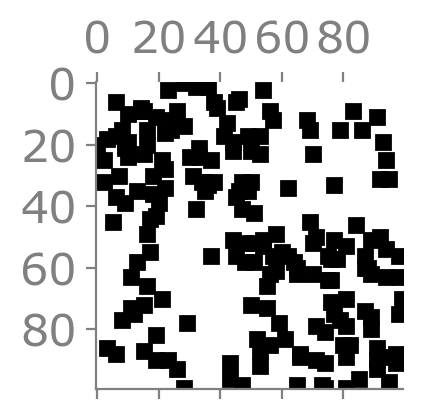

In [93]:
B = bsbm.A[:n1, n1:]
plt.figure(figsize=(2, 2), layout="constrained")
plt.spy(B, markersize=5, mfc="black", mec="black")

In [96]:
order_set, count = np.unique(B.sum(axis=0), return_counts=True)
index_0 = np.where(order_set==0)
order_set = np.delete(order_set, index_0)
count = np.delete(count, index_0)
index_1 = np.where(order_set==1)
order_set = np.delete(order_set, index_1)
count = np.delete(count, index_1)
print(order_set, count)

[2 3 4 5] [32 21  7  1]


In [98]:
hyper_sizes = [int(n1 / q1)] * q1
hyper_ps = dict()
for order in order_set:
    hyper_ps[order] = np.zeros(tuple([q1]*order))
    # Construct probability tensor dict
    for index in itertools.product(range(q1), repeat=order):
        p = 0
        for q in range(q2):
            prod = 1
            # for psi in np.unique(index):
            #     num_psi = Counter(index)[psi] if psi in Counter(index).keys() else 0
            #     prod *= math.comb(int(n1/q1), num_psi)
            for psi in index:
                prod *= H[psi, q]
            for _q in range(q1):
                num__q = Counter(index)[_q] if _q in Counter(index).keys() else 0
                prod *= (1-H[_q, q])**(n1/q1-num__q)
            prod *= n2/q2
            p += prod
        p = p
        hyper_ps[order][index] = p
print(hyper_ps)
hsbm = HyperSBM(hyper_sizes, hyper_ps, slow=False)

{2: array([[0.00698285, 0.00412155],
       [0.00412155, 0.00698285]]), 3: array([[[2.01946871e-04, 8.45512566e-05],
        [8.45512566e-05, 8.45512566e-05]],

       [[8.45512566e-05, 8.45512566e-05],
        [8.45512566e-05, 2.01946871e-04]]]), 4: array([[[[6.10418908e-06, 2.18145783e-06],
         [2.18145783e-06, 1.28758259e-06]],

        [[2.18145783e-06, 1.28758259e-06],
         [1.28758259e-06, 2.18145783e-06]]],


       [[[2.18145783e-06, 1.28758259e-06],
         [1.28758259e-06, 2.18145783e-06]],

        [[1.28758259e-06, 2.18145783e-06],
         [2.18145783e-06, 6.10418908e-06]]]]), 5: array([[[[[1.87359147e-07, 6.30886821e-08],
          [6.30886821e-08, 2.64140133e-08]],

         [[6.30886821e-08, 2.64140133e-08],
          [2.64140133e-08, 2.64140133e-08]]],


        [[[6.30886821e-08, 2.64140133e-08],
          [2.64140133e-08, 2.64140133e-08]],

         [[2.64140133e-08, 2.64140133e-08],
          [2.64140133e-08, 6.30886821e-08]]]],



       [[[[6.30886821e-0

100%|██████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 4094.50it/s]


	 group set (0, 1) have 10 hedges


100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<?, ?it/s]


	 group set (1, 1) have 8 hedges


...

0it [00:00, ?it/s]


	 group set (0, 1, 1, 1, 1) have 0 hedges


0it [00:00, ?it/s]


	 group set (1, 1, 1, 1, 1) have 0 hedges


0it [00:00, ?it/s]


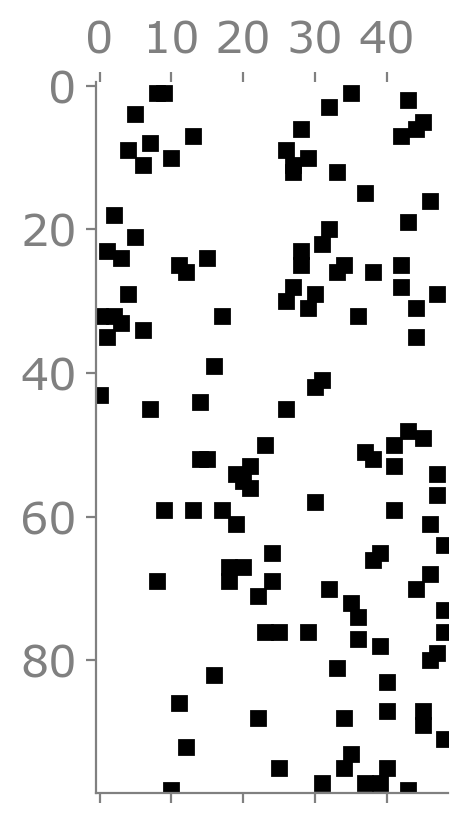

In [101]:
plt.figure(figsize=(4, 4), layout="constrained")
plt.spy(hsbm.H, markersize=5, mfc="black", mec="black")

# Detectability with degree increasing

Start with one-to-one connection bipartite network, $d=1$, and increase $d$ with fixed $\delta$.

$\delta=\frac{n1/q1}{(n1/q1)^2}=\frac{q1}{n1}$

In [10]:
n1 = 100
bsbm, partition, numgroups, ami, snr_full, snr_sub1 = symBSBM()
lefttop = csr_array(np.zeros((n1, n1)))
rightbottom = csr_array(np.zeros((n1, n1)))
righttop = csr_array(np.identity(n1))
leftbottom = csr_array(np.identity(n1))
bsbm.A = csr_array(vstack([hstack([lefttop, righttop]), hstack([leftbottom, rightbottom])])) # Force bsbm B is identity, form one-to-one projection
partition, numgroups = CommunityDetect(bsbm.A).BetheHessian(num_groups=None)
ami = adjusted_mutual_info_score(bsbm.groupId, partition)
print(f'Detect {numgroups} communities, the AMI of partition is {ami}') if verbose else None

a=0.02, b=0.0
[0.02 0.02]
SNR of full bipartite network is 1.0, the first partite is 1.0
number of groups = 0, Kpos=0, Kneg=0
no indication for grouping -- return all in one partition
Detect 0 communities, the AMI of partition is 0.0


D:\Work\PhD\_code\_nodeclassification\spectralOperator.py:87: DeprecationWarning: invalid escape sequence '\d'
  """


ArpackNoConvergence: ARPACK error -1: No convergence (2001 iterations, 9/10 eigenvectors converged)

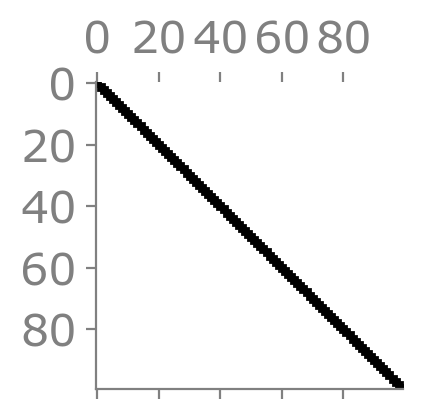

In [41]:
# B = bsbm.A[:n1, n1:]
plt.figure(figsize=(2, 2), layout="constrained")
plt.spy(bsbm.A[:n1, n1:], markersize=2, mfc="black", mec="black")

In [3]:
def scatter_spectral(eigvalue, fig=None, ax=None, title='Spectrum', title_x=0.25):
    # Construct scatter coordinate
    x = []
    y = []
    for _w in eigvalue:
        _x = _w.real if isinstance(_w, complex) else _w
        _y = _w.imag if isinstance(_w, complex) else 0
        x.append(_x)
        y.append(_y)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 8))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    ax.set_aspect('equal',adjustable='box')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
#     ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data', 0))
#     ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data', 0))
    ax.scatter(x, y, s=6)
    ax.set_title(title, x=title_x, y=1.07)

In [4]:
def plot_spectral_NBBH(sbm, bulk, extend_vline=2.65, eig_B=None, ylabel_coor1=(0.25,0.95), ylabel_coor2=(0.2,0.95), 
                       title_x=0.25, eigBH_amplify=1, xlabel_x=1.02, title=r"Spectrum of $\mathrm{NB}$", ax=None, fig=None):
#     print(f'SNR={sbm.get_SNR()}, d={d}')
    if eig_B is None:
        NB = sbm.get_operator('NB')
        print(np.shape(NB))
        eig_B, _ = eig(NB.toarray())
    info_eig = []
    for e in eig_B:
        if abs(e) > bulk and e.imag == 0:
            info_eig.append(e)
    es, counts = np.unique(info_eig, return_counts=True)
    eig_multi = dict(zip(es, counts))
    print({e.real:eig_multi[e] for e in info_eig})
    if ax is None:
        fullfig = plt.figure(figsize=(4, 4), layout="constrained")
        subfigs = fullfig.subfigures(1, 1, wspace=0.1, hspace=0.1)
        axs = subfigs.subplots(1, 1, sharex=True)
        ax0 = axs
    else:
        subfigs=fig
        ax0 = ax
    scatter_spectral(eig_B, fig=subfigs, ax=ax0, title=title, title_x=title_x)
    ax0.add_patch(Circle(xy = (0.0, 0.0), radius=bulk, alpha=0.2))
    for e in info_eig:
        ax0.axvline(e.real, c='black', ls=':', lw=1)
    ax0.set_xlabel('real', loc='right', size=15)
    ax0.set_ylabel('imag', loc='top', size=15)
    ax0.yaxis.set_label_coords(ylabel_coor1[0],ylabel_coor1[1])
    ax0.xaxis.set_label_coords(xlabel_x, 0.4)
    y_locs, y_ticks = plt.yticks()
    x_locs, x_ticks = plt.xticks()

In [16]:
def symBSBM(n1=100, q1=2, delta=0.02, d=1, showMat=False, verbose=True):
    n2 = n1
    q2 = q1
    sizes = [int(n1 / q1)] * q1 + [int(n2 / q2)] * q2
    a = d/n1-delta/q1+delta
    b = d/n1-delta/q1
    if a < 0 or a > 1 or b < 0 or b > 1:
        return None, None, None, None, None
    print(f'a={a}, b={b}') if verbose else None
    H = (a - b) * np.identity(q1) + b * np.ones((q1, q2))
    bsbm = BipartiteSBM(q1, q2, sizes, H)
    H_svalues = bsbm.getSingulars()
    print(H_svalues) if verbose else None
    snr_full = n1 / q1 * H_svalues[0]
    snr_sub1 = n1 / q1* H_svalues[1]**2 / H_svalues[0]
    print(f'SNR of full bipartite network is {snr_full}, the first partite is {snr_sub1}') if verbose else None
    partition, numgroups = CommunityDetect(bsbm.A).BetheHessian(num_groups=None)
    ami = adjusted_mutual_info_score(bsbm.groupId, partition)
    print(f'Detect {numgroups} communities, the AMI of partition is {ami}') if verbose else None
    if showMat:
        plt.figure(figsize=(1, 1), layout="constrained")
        plt.matshow(bsbm.A[:n1, n1:].toarray())
        plt.title("B")
    return bsbm, partition, numgroups, ami, snr_full, snr_sub1

## d=1, find 2 communities

a=0.02, b=0.0
[0.02 0.02]
SNR of full bipartite network is 1.0, the first partite is 1.0
number of groups = 2, Kpos=1, Kneg=1
Detect 2 communities, the AMI of partition is 0.10131463347476609


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Figure size 100x100 with 0 Axes>

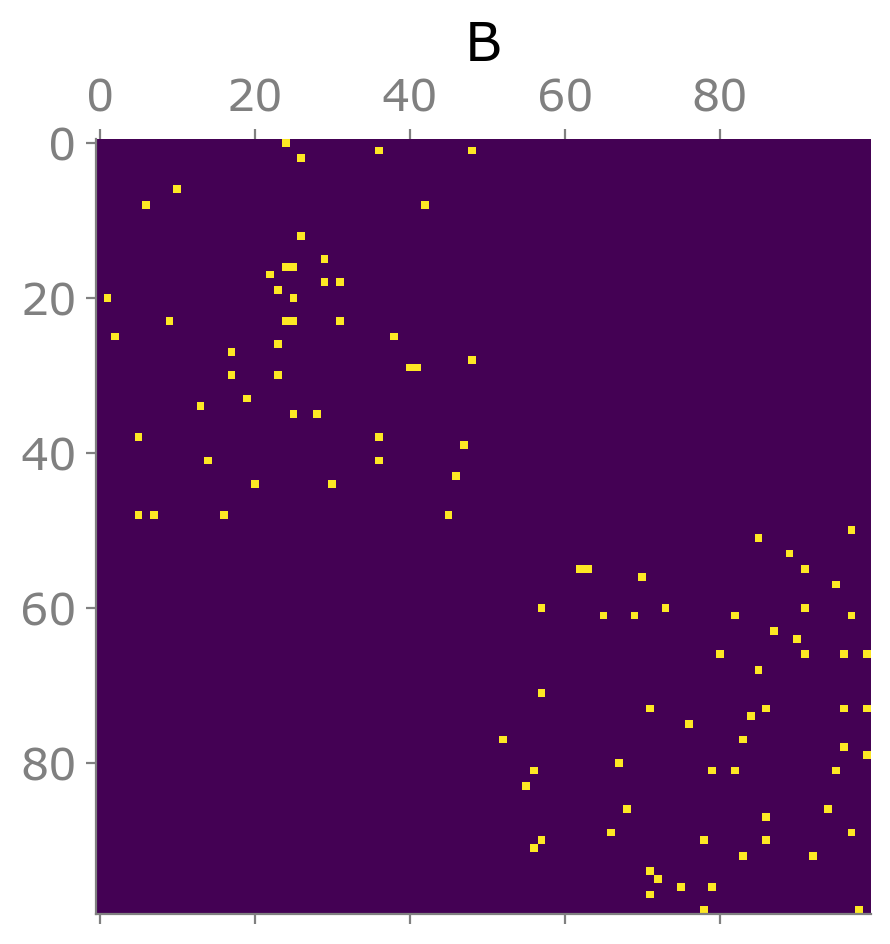

In [63]:
bsbm, partition, ami = symBSBM(showMat=True)

(206, 206)
{-1.2424528211131731: 1, 1.2424528211131687: 1, -1.0000000000000004: 1, 1.0000000000000004: 1, -1.0000000000000018: 1, 1.0000000000000013: 1}


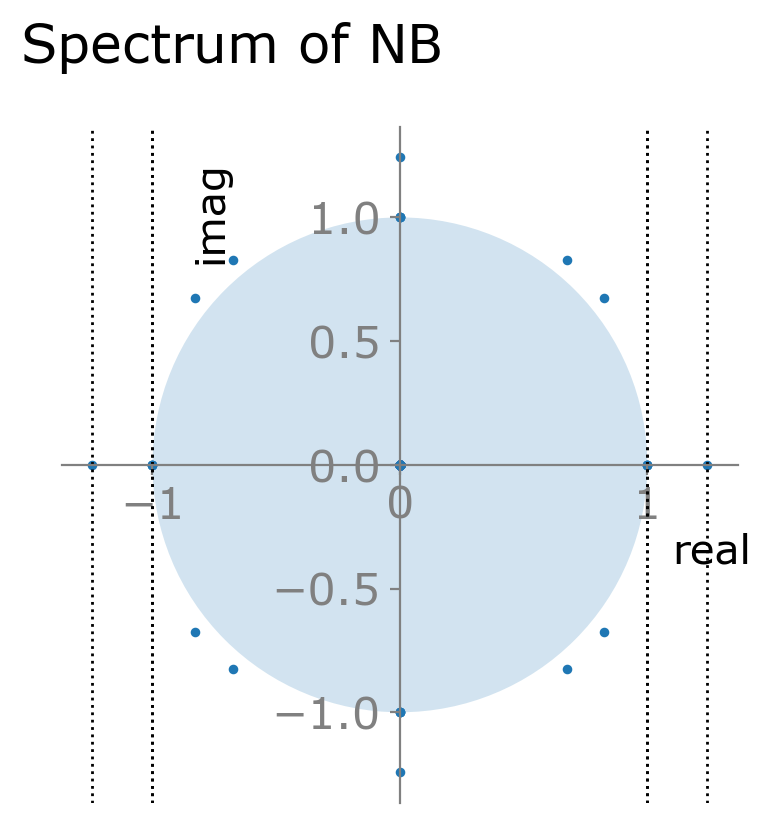

In [64]:
plot_spectral_NBBH(bsbm, bulk=np.sqrt(d))

## d=1, find 0 communities

a=0.02, b=0.0
[0.02 0.02]
SNR of full bipartite network is 1.0, the first partite is 1.0
number of groups = 0, Kpos=0, Kneg=0
no indication for grouping -- return all in one partition
Detect 0 communities, the AMI of partition is 0.0


<Figure size 100x100 with 0 Axes>

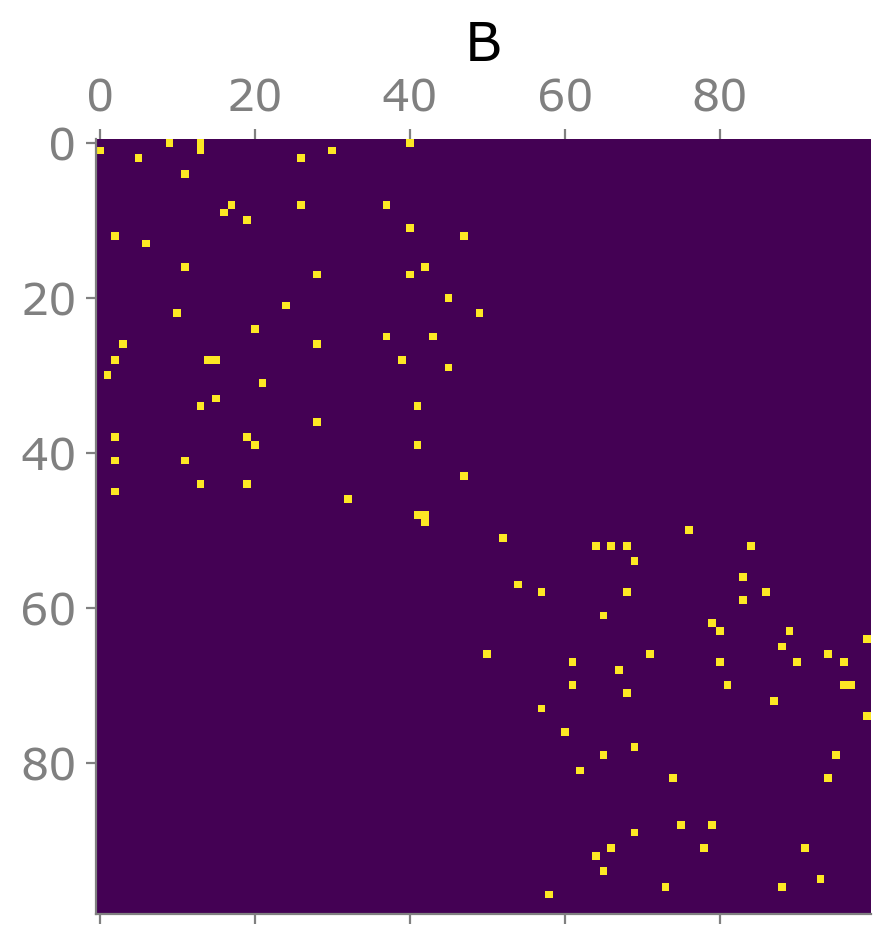

In [65]:
bsbm, partition, ami = symBSBM(showMat=True)

(220, 220)
{-1.0000000000000009: 2, -1.0000000000000004: 2}


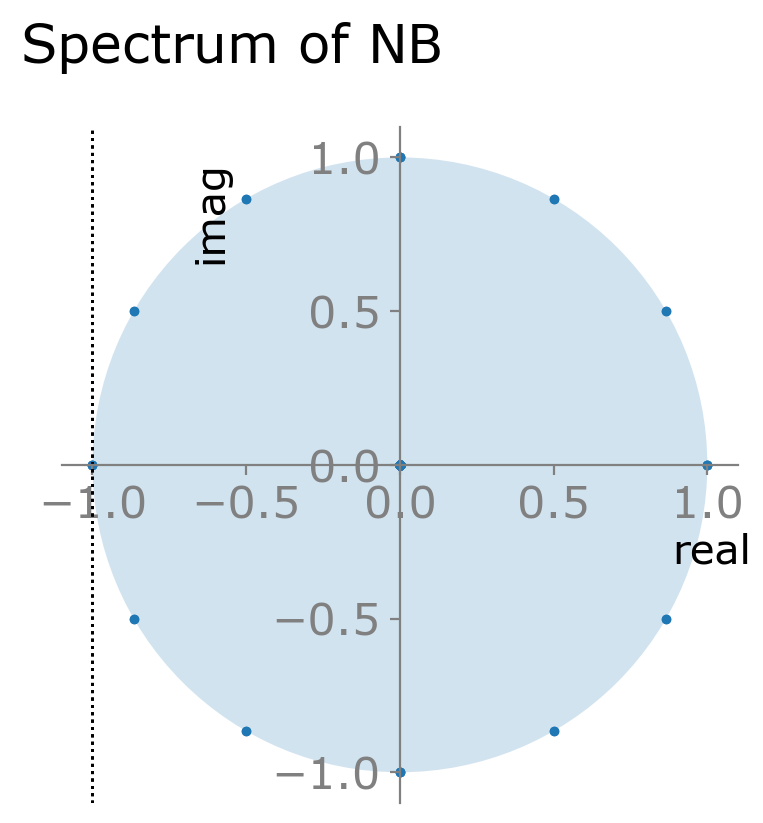

In [66]:
plot_spectral_NBBH(bsbm, bulk=np.sqrt(d))

## d=1, find n communities

a=0.02, b=0.0
[0.02 0.02]
SNR of full bipartite network is 1.0, the first partite is 1.0
Try first 100 eigenvalue...
Try first 199 eigenvalue...
Try first 100 eigenvalue...
Try first 199 eigenvalue...
number of groups = 200, Kpos=107, Kneg=107
Detect 200 communities, the AMI of partition is 7.060886097639097e-14


<Figure size 100x100 with 0 Axes>

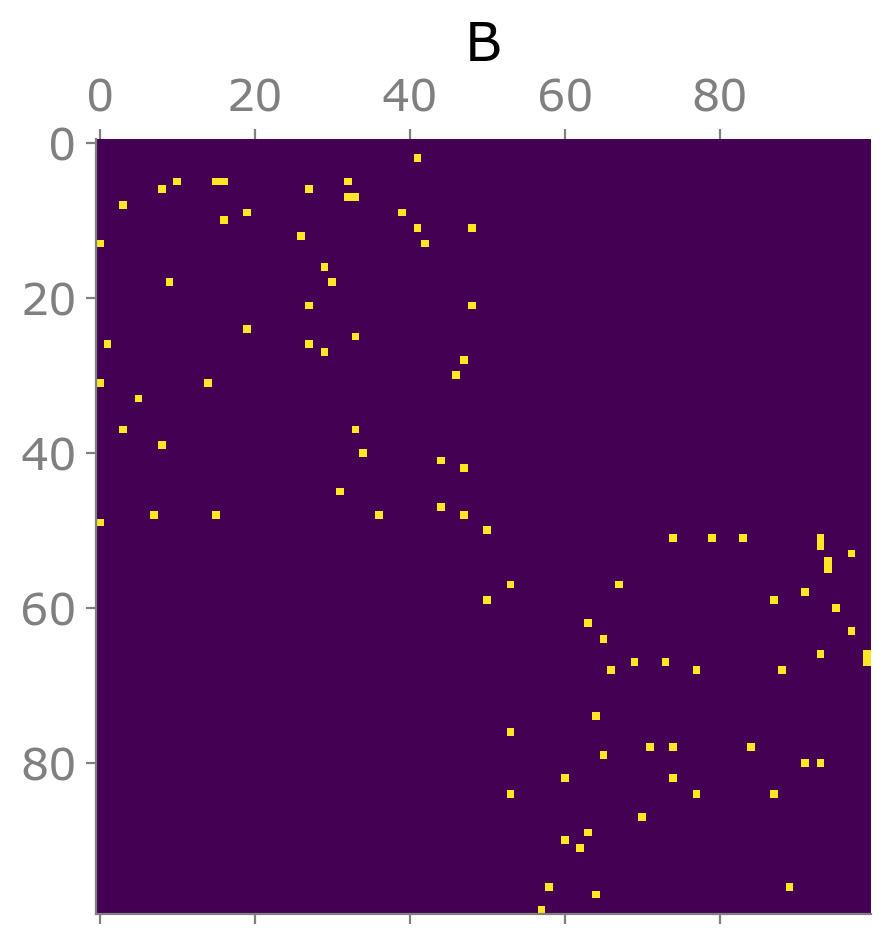

In [67]:
bsbm, partition, ami = symBSBM(showMat=True)

(186, 186)
{}


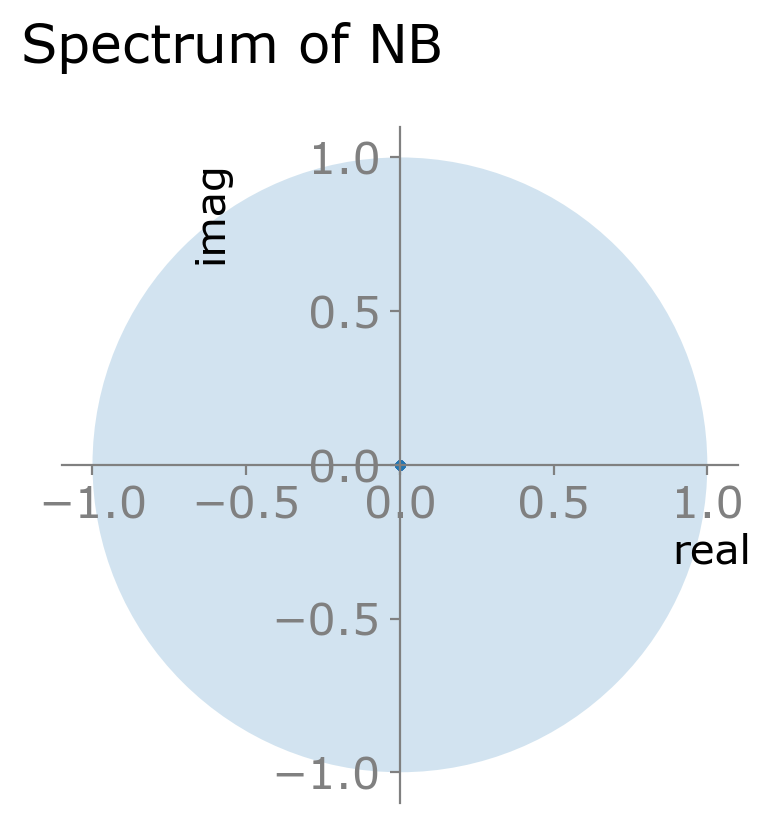

In [68]:
plot_spectral_NBBH(bsbm, bulk=np.sqrt(d))

## increase d
if keep delta unchange as $q1/n1$, then with $d>1$, the part1 is always undetectable

In [4]:
n1=100
q1=2
max_d = 5
deltas = np.linspace(0, min((q1-q1/n1*max_d)/(q1-1), q1/n1*max_d), 41)
ds = np.hstack((np.linspace(0.5, 1, 21), np.linspace(1.2, max_d, 20)))
full_snrs = []
sub1_snrs = []
for d in tqdm(ds):
    for delta in deltas:
        n2 = n1
        q2 = q1
        sizes = [int(n1 / q1)] * q1 + [int(n2 / q2)] * q2
        a = d/n1-delta/q1+delta
        b = d/n1-delta/q1
        if a <= 1e-6 or a >= 1 or b <= 1e-6 or b >= 1:
            full_snrs.append(np.inf)
            sub1_snrs.append(np.inf)
            continue
        # print(f'a={a}, b={b}')
        H = (a - b) * np.identity(q1) + b * np.ones((q1, q2))
        bsbm = BipartiteSBM(q1, q2, sizes, H)
        H_svalues = bsbm.getSingulars()
        snr_full = n1 / q1 * H_svalues[0]
        snr_sub1 = n1 / q1* H_svalues[1]**2 / H_svalues[0]
        full_snrs.append(snr_full)
        sub1_snrs.append(snr_sub1)
full_snrs = np.array(full_snrs)
sub1_snrs = np.array(sub1_snrs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [00:02<00:00, 16.41it/s]


In [5]:
tag = "symmetricB_acrossD=1"
fileID = 'amiExp25.2.1' + f'_n1={n1}_q1={q1}_{tag}'
save_path = "./result/detectabilityBipartite/" + fileID + ".txt"
plot_ds, plot_deltas, Results = read_exp(load_path=save_path)
full_ami = [np.around(r[1], 1) + 0 for r in Results]
sub1_ami = [np.around(r[4], 1) + 0 for r in Results]
# full_ami = [100 if a==-1 else a for a in full_ami]
# sub1_ami = [100 if a==-1 else a for a in sub1_ami]
full_amis = np.array(full_ami)
sub1_amis = np.array(sub1_ami)

full_numgroup = [r[0] + 0 for r in Results]
sub1_numgroup = [r[3] + 0 for r in Results]
full_numgroups = np.array(full_numgroup)
sub1_numgroups = np.array(sub1_numgroup)

In [180]:
print(np.unique([ami if (ami<0) else 0 for ami in full_ami]))

[0]


minz=0, maxz=1, cticks=[0, 1], clabel=['0.0', '1.0']
minz=0, maxz=1, cticks=[0, 1], clabel=['0.0', '1.0']
minz=-1.0, maxz=200.0, cticks=[0, 1], clabel=['1.0', '200.0']
minz=-1.0, maxz=100.0, cticks=[0, 1], clabel=['1.0', '100.0']


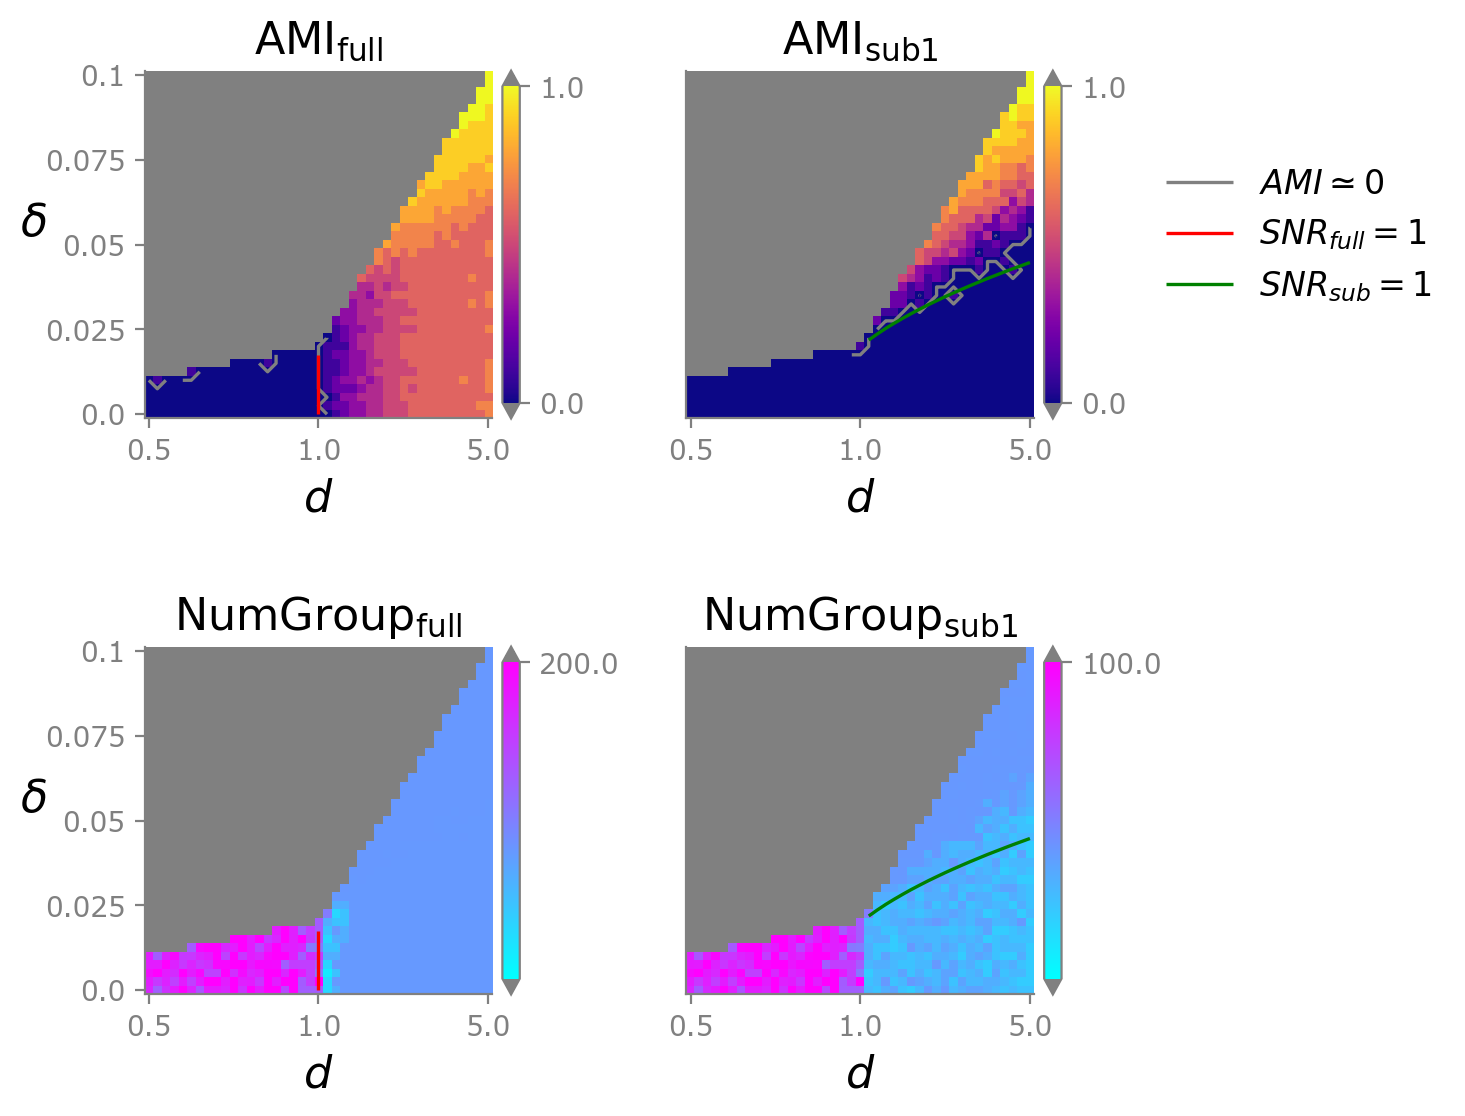

In [214]:
fig = plt.figure(figsize=(6.2, 6))
widths = [3, 3]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
handels = []
cmap = mpl.colormaps["plasma"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
# print(cmap)
plot_fullami = color_imshow_2d(plot_ds, plot_deltas, full_amis, z_center=0.5, title=r"$\rm AMI_{full}$", xlabel=r"$d$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=False, vmin=0, vmax=1, ytickprecision=3, cticks=[0, 1])
filtered_plot_fullami = np.where(np.abs(plot_fullami) < 0.5, plot_fullami, np.nan)
handels += contour_data(filtered_plot_fullami, ax, levels=[1e-4], fmt={1e-4: r'$AMI$\simeq$0$'}, color='gray', inline=False)
xtickpos = np.linspace(0, np.size(ds)-1, 3)
xticks = [np.around(ds[int(xi)], 3) for xi in xtickpos]
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_fullsnr = color_imshow_2d(plot_ds, plot_deltas, full_snrs, z_center=1, min_z=0, max_z=np.max(full_snrs), return_gridz=True)
handels += contour_data(plot_fullsnr, ax, levels=[1], fmt={1: r'$SNR_{full}=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_sub1ami = color_imshow_2d(plot_ds, plot_deltas, sub1_amis, z_center=0.5, title=r"$\rm AMI_{sub1}$", xlabel=r"$d$", ylabel=r"", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=False, set_yticks=False, vmin=0, vmax=1, ytickprecision=3,
                    cticks=[0, 1])
filtered_plot_sub1ami = np.where(np.abs(plot_sub1ami) < 0.5, plot_sub1ami, np.nan)
contour_data(filtered_plot_sub1ami, ax, levels=[1e-4], fmt={1e-4: r'$AMI$\simeq$0$'}, color='gray', inline=False)
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, return_gridz=True)
handels += contour_data(plot_sub1snr, ax, levels=[1], fmt={1: r'$SNR_{sub}=1$'}, color='green', inline=False)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
# print(cmap)
plot_fullnumgroup = color_imshow_2d(plot_ds, plot_deltas, full_numgroups, z_center=2, title=r"$\rm NumGroup_{full}$", xlabel=r"$d$", ylabel=r"$\delta$", 
                cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=False, vmin=0, ytickprecision=3, cticks=[0, 1])
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_fullsnr = color_imshow_2d(plot_ds, plot_deltas, full_snrs, z_center=1, min_z=0, max_z=np.max(full_snrs), return_gridz=True)
contour_data(plot_fullsnr, ax, levels=[1], fmt={1: r'$SNR_{full}=1$'}, color='red', inline=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_sub1numgroup = color_imshow_2d(plot_ds, plot_deltas, sub1_numgroups, z_center=2, title=r"$\rm NumGroup_{sub1}$", xlabel=r"$d$", ylabel=r"", 
                cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=False, set_yticks=False, vmin=0, ytickprecision=3,
                    cticks=[0, 1])
ax.set_xticks(xtickpos, xticks, fontsize=10)
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, return_gridz=True)
contour_data(plot_sub1snr, ax, levels=[1], fmt={1: r'$SNR_{sub}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$AMI\simeq 0$', r'$SNR_{full}=1$', r'$SNR_{sub}=1$'], loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.tight_layout()

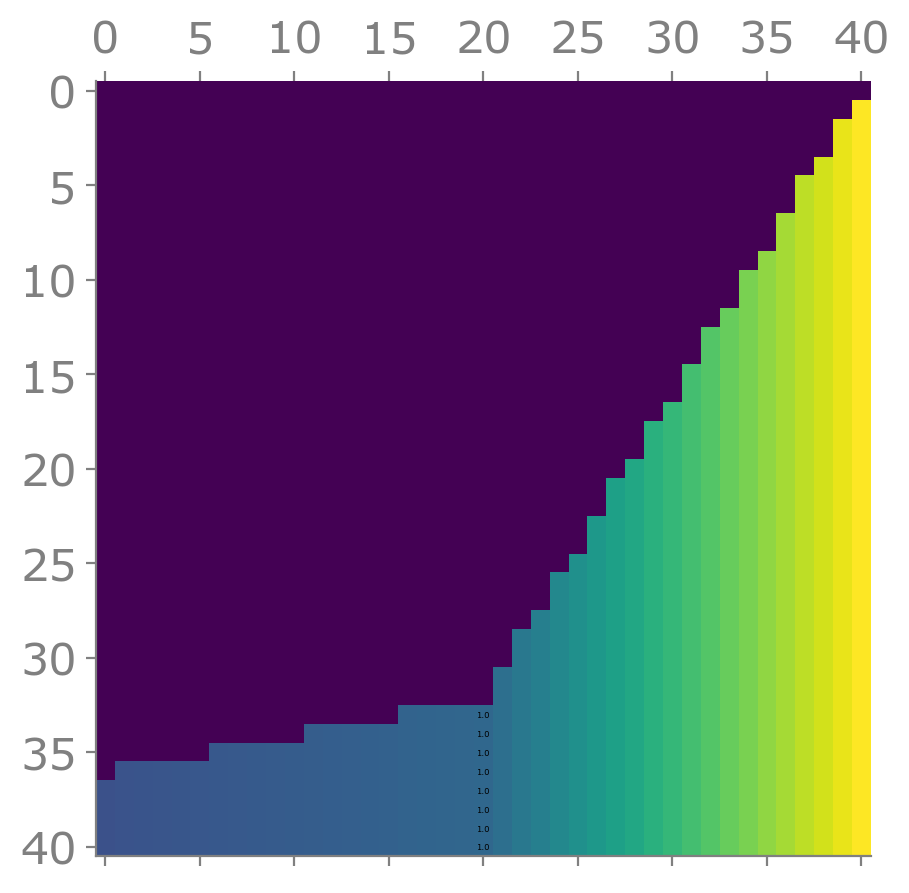

In [120]:
plot_ds = np.repeat(ds, np.size(deltas))
plot_deltas = np.tile(deltas, np.size(ds))
full_snrs = np.array(full_snrs)
cmap = mpl.colormaps["plasma"]
plot_fullsnr = color_imshow_2d(plot_ds, plot_deltas, full_snrs, z_center=1, title=f"SNR of full", xlabel=r"$d$", ylabel=r"$\delta$", 
                                min_z=0, cmap=cmap, return_gridz=True, vmin=0, ytickprecision=3)
show_fullsnr = np.flip(plot_fullsnr, axis=0)
plt.matshow(show_fullsnr)
shape = np.shape(show_fullsnr)
for i in range(shape[0]):
    for j in range(shape[1]):
        if 1-1e-6 < show_fullsnr[i,j] < 1+1e-6:
            c = np.around(show_fullsnr[i,j], 1)
            plt.text(j, i, str(c), va='center', ha='center', fontsize=3)

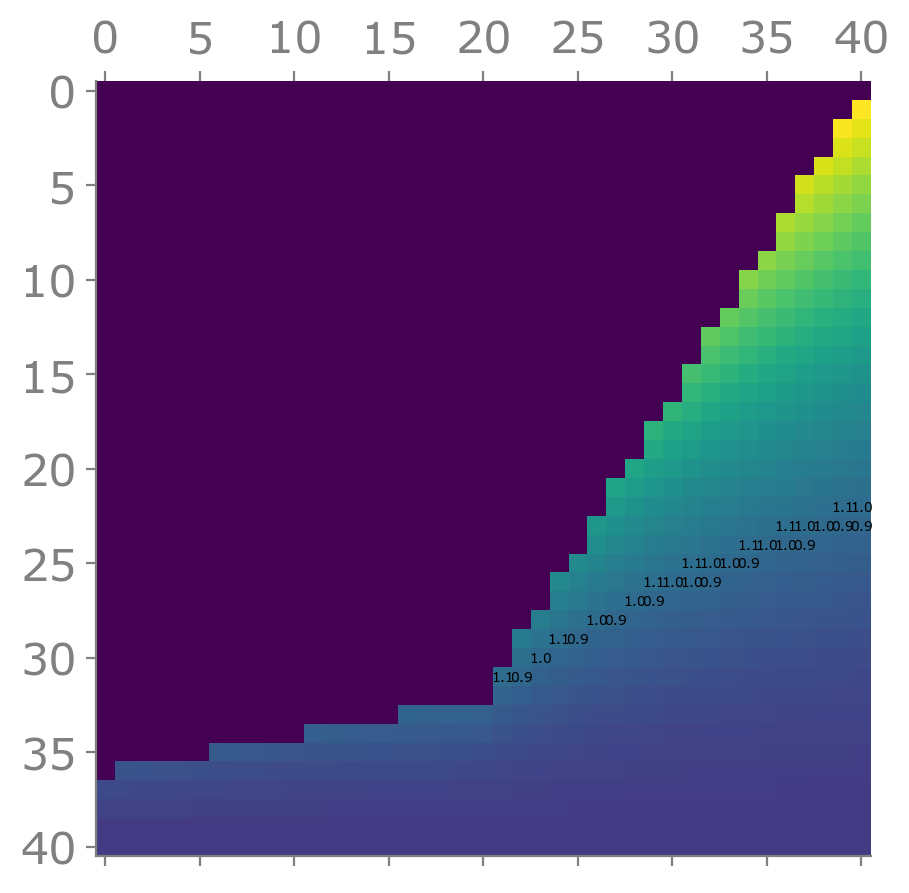

In [123]:
sub1_snrs = np.array(sub1_snrs)
cmap = mpl.colormaps["plasma"]
plot_sub1snr = color_imshow_2d(plot_ds, plot_deltas, sub1_snrs, z_center=1, title=f"SNR of sub1", xlabel=r"$d$", ylabel=r"$\delta$", 
                                min_z=0, cmap=cmap, return_gridz=True, vmin=0, ytickprecision=3)
show_sub1snr = np.flip(plot_sub1snr, axis=0)
plt.matshow(show_sub1snr)
shape = np.shape(show_sub1snr)
for i in range(shape[0]):
    for j in range(shape[1]):
        if 1-1e-1 < show_sub1snr[i,j] < 1+1e-1:
            c = np.around(show_sub1snr[i,j], 1)
            plt.text(j, i, str(c), va='center', ha='center', fontsize=5)

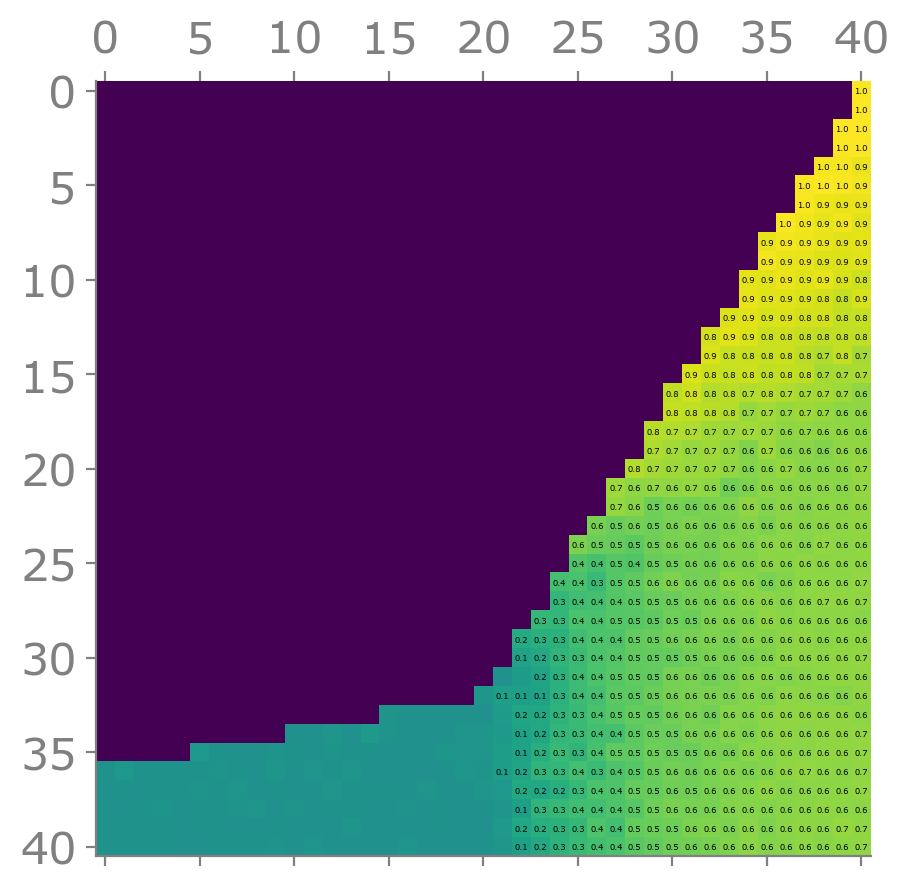

In [130]:
full_amis = np.array(full_ami)
cmap = mpl.colormaps["plasma"]
plot_fullami = color_imshow_2d(plot_ds, plot_deltas, full_amis, z_center=0.5, title=f"SNR of sub1", xlabel=r"$d$", ylabel=r"$\delta$", 
                                min_z=0, cmap=cmap, return_gridz=True, vmin=0, ytickprecision=3)
show_fullami = np.flip(plot_fullami, axis=0)
plt.matshow(show_fullami)
shape = np.shape(show_fullami)
for i in range(shape[0]):
    for j in range(shape[1]):
        if show_fullami[i,j] > 1e-1:
            c = np.around(show_fullami[i,j], 1)
            plt.text(j, i, str(c), va='center', ha='center', fontsize=3)

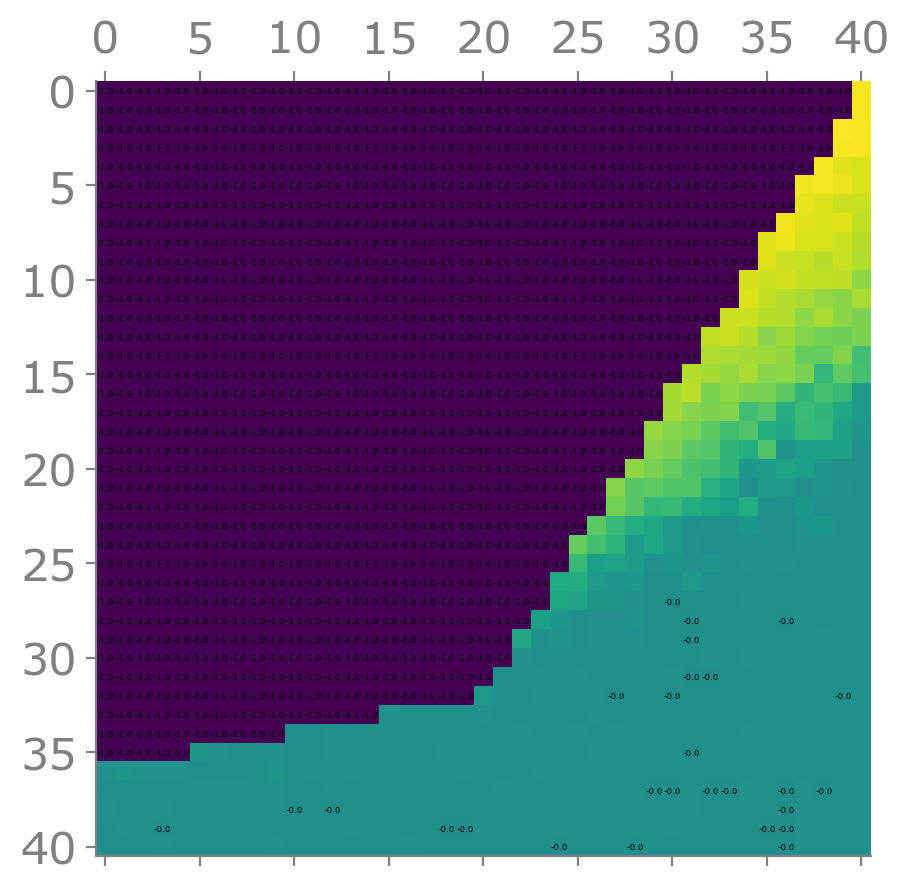

In [169]:
sub1_amis = np.array(sub1_ami)
cmap = mpl.colormaps["plasma"]
plot_sub1ami = color_imshow_2d(plot_ds, plot_deltas, sub1_amis, z_center=0.5, title=f"SNR of sub1", xlabel=r"$d$", ylabel=r"$\delta$", 
                                min_z=0, cmap=cmap, return_gridz=True, vmin=0, ytickprecision=3)
show_sub1ami = np.flip(plot_sub1ami, axis=0)
plt.matshow(show_sub1ami)
shape = np.shape(show_sub1ami)
for i in range(shape[0]):
    for j in range(shape[1]):
        # if show_sub1ami[i,j] > 1e-1:
        if show_sub1ami[i,j] < 0:
            c = np.around(show_sub1ami[i,j], 1)
            plt.text(j, i, str(c), va='center', ha='center', fontsize=3)

([], [])

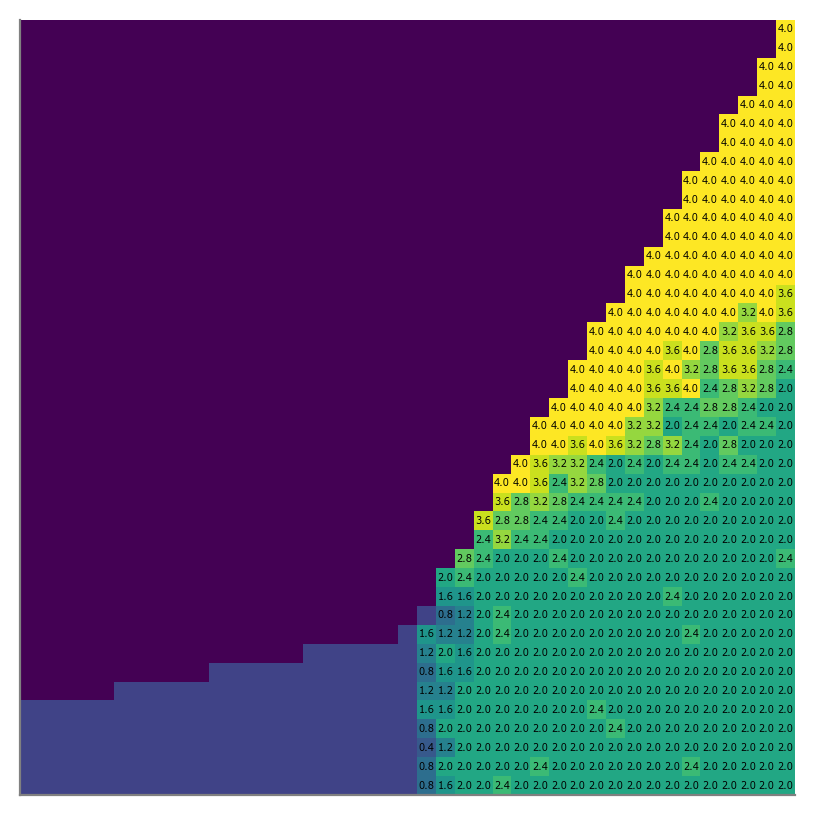

In [10]:
cmap = mpl.colormaps["cool"]
plot_fullnumgroup = color_imshow_2d(plot_ds, plot_deltas, full_numgroups, z_center=0.5, title=f"NumGroup of full", xlabel=r"$d$", ylabel=r"$\delta$", 
                                min_z=0, cmap=cmap, return_gridz=True, vmin=0, ytickprecision=3)
show_fullnumgroup = np.flip(plot_fullnumgroup, axis=0)
show_fullnumgroup[np.where(show_fullnumgroup>5)] = 0
plt.matshow(show_fullnumgroup)
shape = np.shape(show_fullnumgroup)
for i in range(shape[0]):
    for j in range(shape[1]):
        if 0 < show_fullnumgroup[i,j] <= 4:
            c = np.around(show_fullnumgroup[i,j], 1)
            plt.text(j, i, str(c), va='center', ha='center', fontsize=3.5)
plt.xticks([])
plt.yticks([])

([], [])

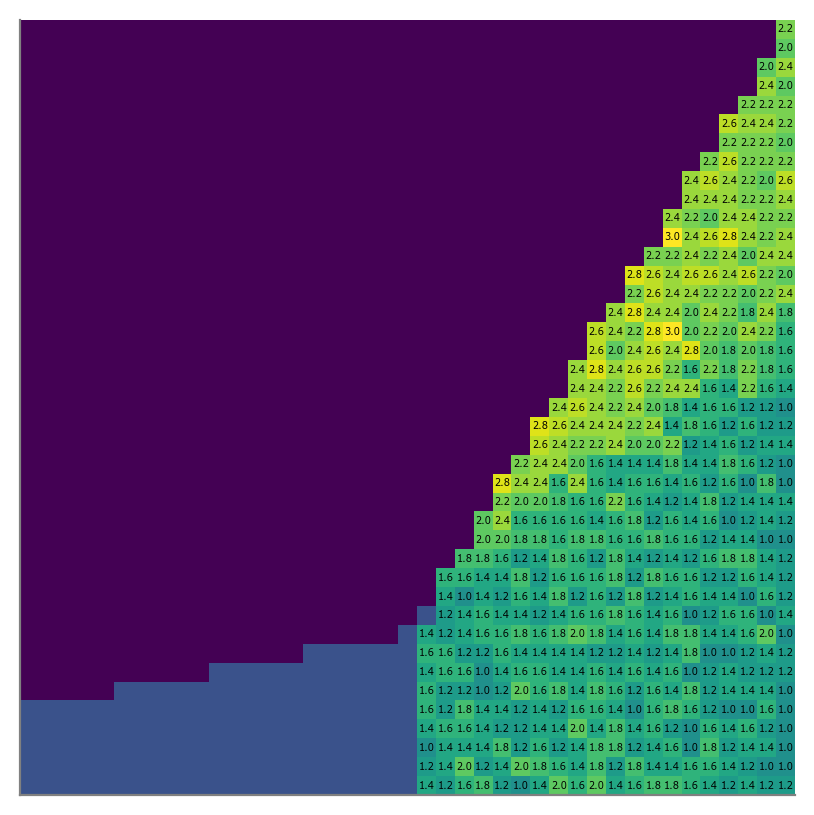

In [11]:
cmap = mpl.colormaps["cool"]
plot_sub1numgroup = color_imshow_2d(plot_ds, plot_deltas, sub1_numgroups, z_center=0.5, title=f"NumGroup of full", xlabel=r"$d$", ylabel=r"$\delta$", 
                                min_z=0, cmap=cmap, return_gridz=True, vmin=0, ytickprecision=3)
show_sub1numgroup = np.flip(plot_sub1numgroup, axis=0)
show_sub1numgroup[np.where(show_sub1numgroup>5)] = 0
plt.matshow(show_sub1numgroup)
shape = np.shape(show_sub1numgroup)
for i in range(shape[0]):
    for j in range(shape[1]):
        if 0 < show_sub1numgroup[i,j] <= 4:
            c = np.around(show_sub1numgroup[i,j], 1)
            plt.text(j, i, str(c), va='center', ha='center', fontsize=3.5)
plt.xticks([])
plt.yticks([])

## Other type of H

In [18]:
def ami_contour(fig, ax, plot_x, plot_y, ami, addition_contour, ami_contour_value=0.5, zcenter=0.5, ami_label="", add_contour_label="", xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=True):
    cmap = mpl.colormaps["plasma"]
    zcenter = zcenter
    plot_ami = color_imshow_2d(plot_x, plot_y, ami, z_center=zcenter, title=f"AMI of {ami_label}", xlabel=xlabel, ylabel=ylabel, 
                                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, set_yticks=set_yticks, vmin=0, vmax=1, ytickprecision=3)
    print(f'min {ami_label} ami={np.min(np.abs(ami))} max {ami_label} ami={np.max(np.abs(ami))}')
    contour_data(plot_ami, ax, levels=[ami_contour_value], fmt={ami_contour_value: rf'AMI={ami_contour_value}'}, color='white', inline=True)
    contour_data(color_imshow_2d(plot_x, plot_y, addition_contour, z_center=1, return_gridz=True),
                 ax, levels=[1], fmt={1: f'{add_contour_label}=1'}, color='yellow', inline=True)

In [14]:
# For big n
n1 = 3000
n2 = 4000
k1 = 3
k2 = 4
WithlambdaB = True
fileID = 'amiExp24.4.22' + f'_n1={n1}n2={n2}_k1={k1}k2={k2}_{"lambda" if WithlambdaB else ""}_asymmetric_givenNumgroups'
load_path = "./result/detectabilityBipartite/" + fileID + ".txt"
plot_ds, plot_deltas, results, lambdas = read_exp_old(load_path=load_path, WithlambdaB=WithlambdaB, num_result=16)
A_ami, A_num_group, Ahalf1_ami, Ahalf1_num_group, Ahalf2_ami, Ahalf2_num_group, AA_ami, AA_num_group, AAhalf1_ami, AAhalf1_num_group, AAhalf2_ami, AAhalf2_num_group, BBT_ami, BBT_num_group, BTB_ami, BTB_num_group = \
results[0], results[1], results[2], results[3],results[4],results[5],results[6],results[7],results[8],results[9],results[10],results[11],results[12],results[13], results[14], results[15]

minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min A ami=0.350322 max A ami=0.8594060000000001
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min Part 1 ami=0.0 max Part 1 ami=0.8305
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min Part 2 ami=0.0 max Part 2 ami=0.75525
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min $BB^T$ ami=0.0 max $BB^T$ ami=0.75723
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min $B^TB$ ami=0.0 max $B^TB$ ami=0.571118


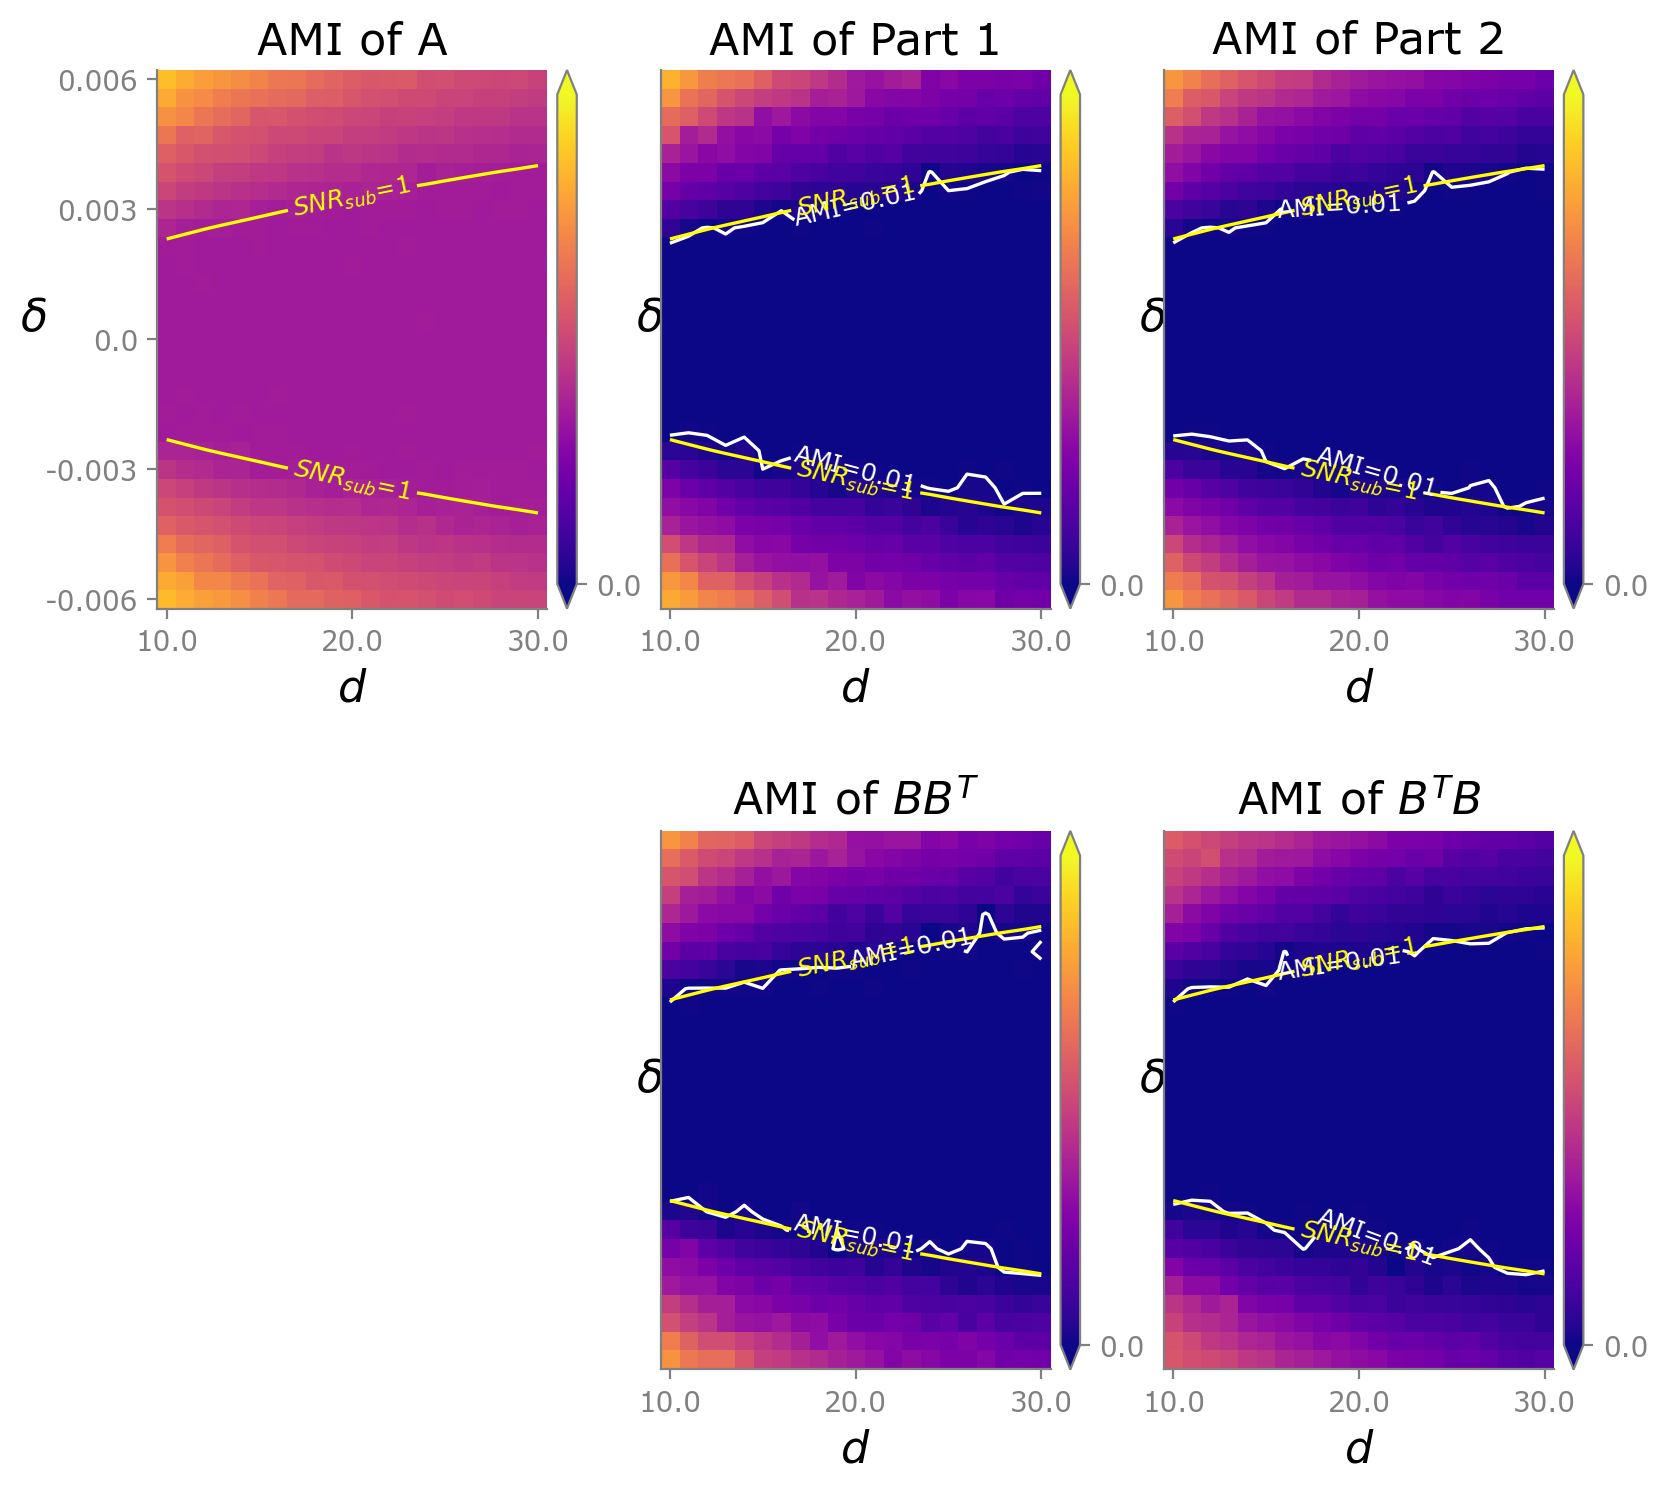

In [24]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(9.2, 14))
widths = [3, 3, 3]
heights = [3, 3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=3, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=A_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=0.1, ami_label="A", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=True)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=Ahalf1_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label="Part 1", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)


row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=Ahalf2_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label="Part 2", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=BBT_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label=r"$BB^T$", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

row = 1
col = 2
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=BTB_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label=r"$B^TB$", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

# plt.subplots_adjust(wspace=0.8)
# save_path = "./_Figure/Bipartite/" + "FigureBipartiteAMISNR_" + f'n1_{n1}_n2_{n2}_k1_{k1}_k2_{k2}' + ".png"
# # # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_inches='tight')

In [25]:
# For big n
n1 = 4000
n2 = 4000
k1 = 4
k2 = 4
WithlambdaB = True
Htype=2
fileID = 'amiExp24.4.23' + f'_n1={n1}n2={n2}_k1={k1}k2={k2}Htype={Htype}_{"lambda" if WithlambdaB else ""}_asymmetric_givenNumgroups'
load_path = "./result/detectabilityBipartite/" + fileID + ".txt"
plot_ds, plot_deltas, results, lambdas = read_exp_old(load_path=load_path, WithlambdaB=WithlambdaB, num_result=16)
A_ami, A_num_group, Ahalf1_ami, Ahalf1_num_group, Ahalf2_ami, Ahalf2_num_group, AA_ami, AA_num_group, AAhalf1_ami, AAhalf1_num_group, AAhalf2_ami, AAhalf2_num_group, BBT_ami, BBT_num_group, BTB_ami, BTB_num_group = \
results[0], results[1], results[2], results[3],results[4],results[5],results[6],results[7],results[8],results[9],results[10],results[11],results[12],results[13], results[14], results[15]

minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min A ami=0.33261 max A ami=0.9569600000000001
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min Part 1 ami=0.0 max Part 1 ami=0.93582
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min Part 2 ami=0.0 max Part 2 ami=0.93514
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min $BB^T$ ami=0.0 max $BB^T$ ami=0.9192079999999999
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min $B^TB$ ami=0.0 max $B^TB$ ami=0.929098


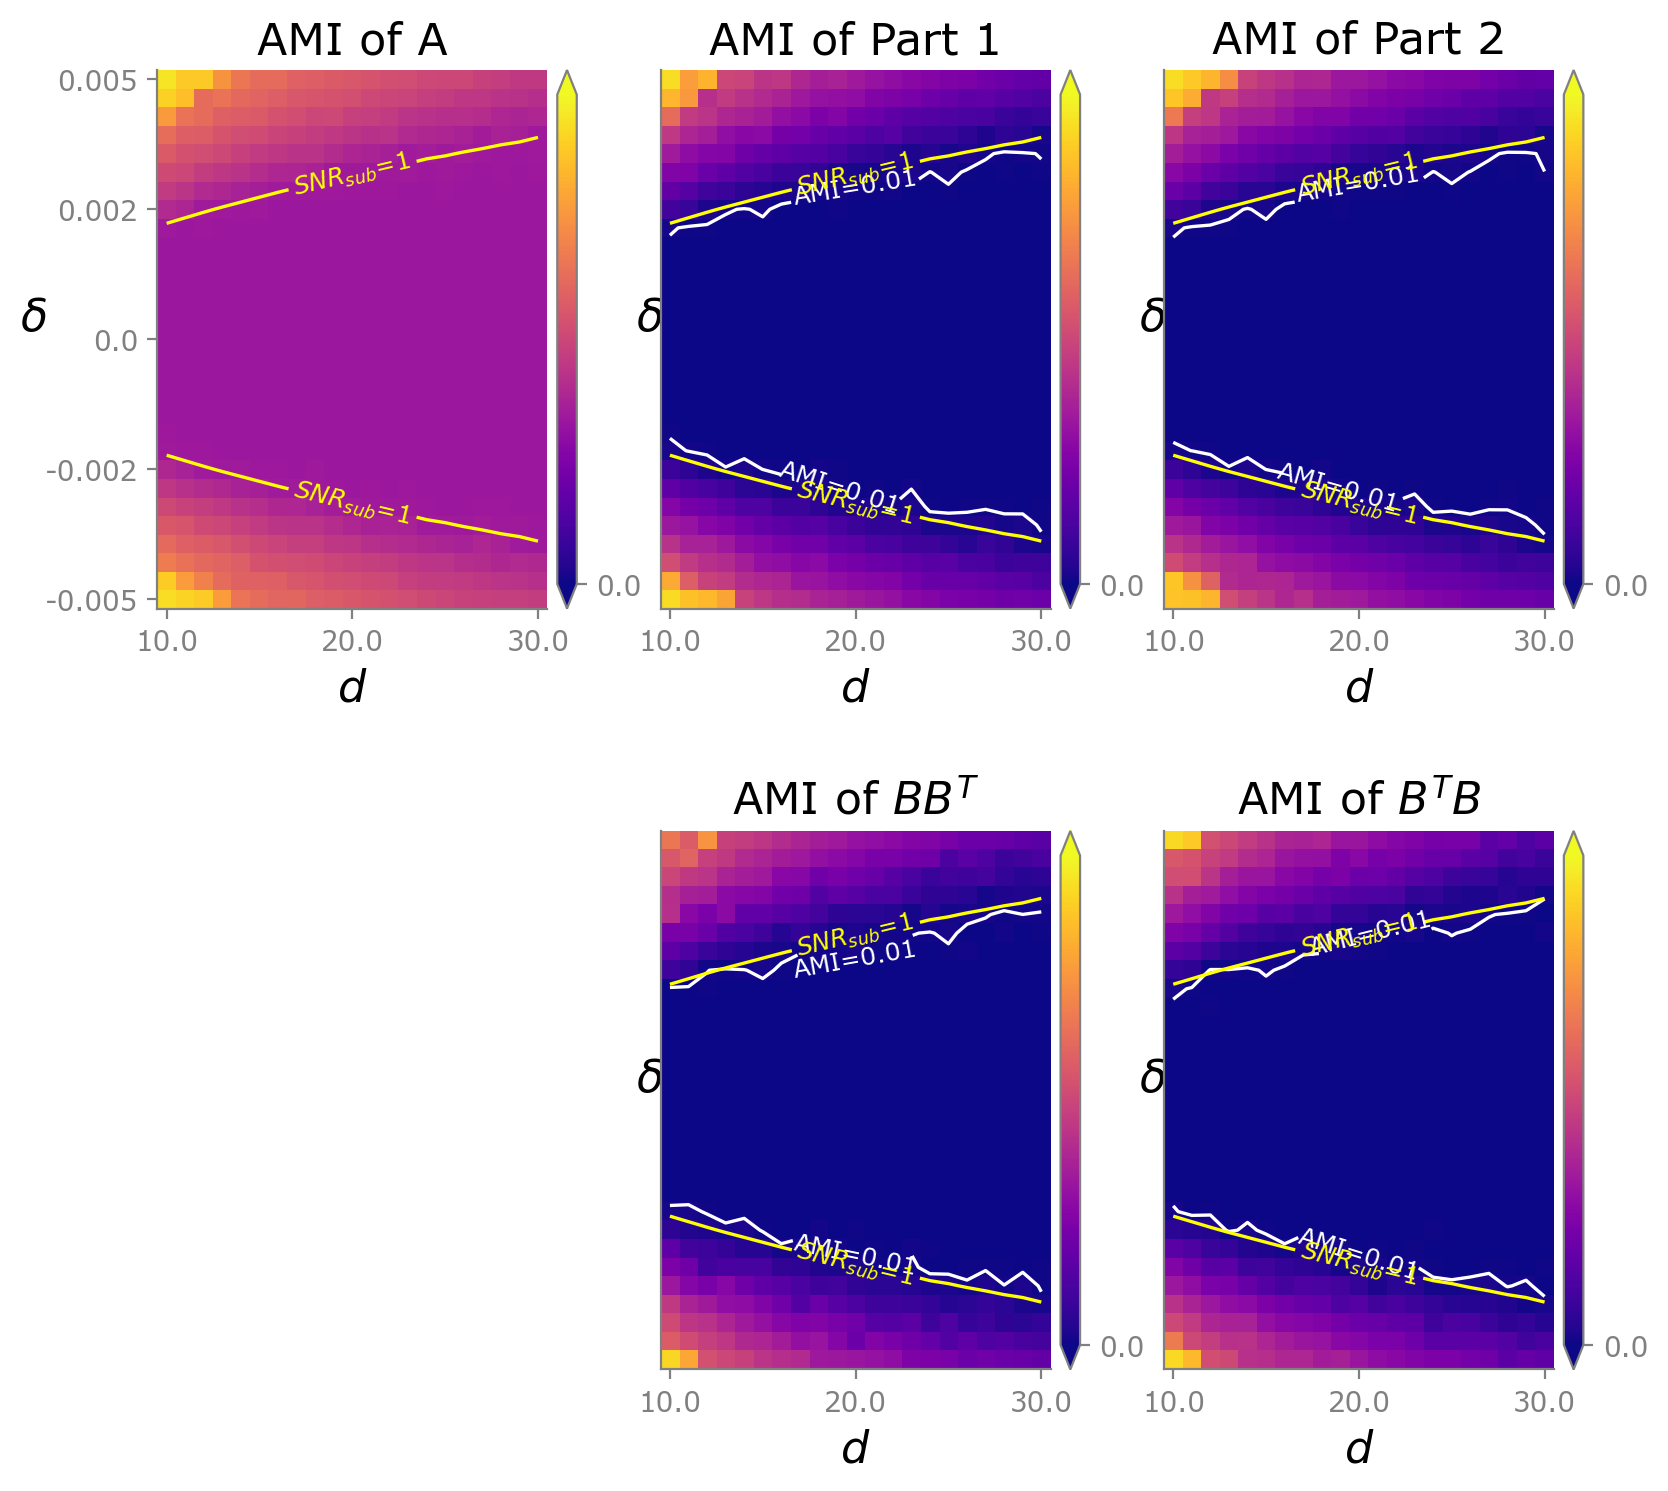

In [26]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(9.2, 14))
widths = [3, 3, 3]
heights = [3, 3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=3, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=A_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=0.1, ami_label="A", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=True)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=Ahalf1_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label="Part 1", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)


row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=Ahalf2_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label="Part 2", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=BBT_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label=r"$BB^T$", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

row = 1
col = 2
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=BTB_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label=r"$B^TB$", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

# plt.subplots_adjust(wspace=0.8)
# save_path = "./_Figure/Bipartite/" + "FigureBipartiteAMISNR_" + f'n1_{n1}_n2_{n2}_k1_{k1}_k2_{k2}' + ".png"
# # # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_inches='tight')

In [28]:
# For big n
n1 = 3000
n2 = 6000
k1 = 3
k2 = 6
WithlambdaB = True
Htype=3
fileID = 'amiExp24.4.26' + f'_n1={n1}n2={n2}_k1={k1}k2={k2}Htype={Htype}_{"lambda" if WithlambdaB else ""}_asymmetric_givenNumgroups'
load_path = "./result/detectabilityBipartite/" + fileID + ".txt"
plot_ds, plot_deltas, results, lambdas = read_exp_old(load_path=load_path, WithlambdaB=WithlambdaB, num_result=16)
A_ami, A_num_group, Ahalf1_ami, Ahalf1_num_group, Ahalf2_ami, Ahalf2_num_group, AA_ami, AA_num_group, AAhalf1_ami, AAhalf1_num_group, AAhalf2_ami, AAhalf2_num_group, BBT_ami, BBT_num_group, BTB_ami, BTB_num_group = \
results[0], results[1], results[2], results[3],results[4],results[5],results[6],results[7],results[8],results[9],results[10],results[11],results[12],results[13], results[14], results[15]

minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min A ami=0.29085 max A ami=0.7988
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min Part 1 ami=0.0 max Part 1 ami=1.0
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min Part 2 ami=0.0 max Part 2 ami=0.6499839999999999
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min $BB^T$ ami=0.0 max $BB^T$ ami=1.0
minz=0, maxz=1, cticks=[0.], clabel=['0.0']
min $B^TB$ ami=0.0 max $B^TB$ ami=0.6161199999999999


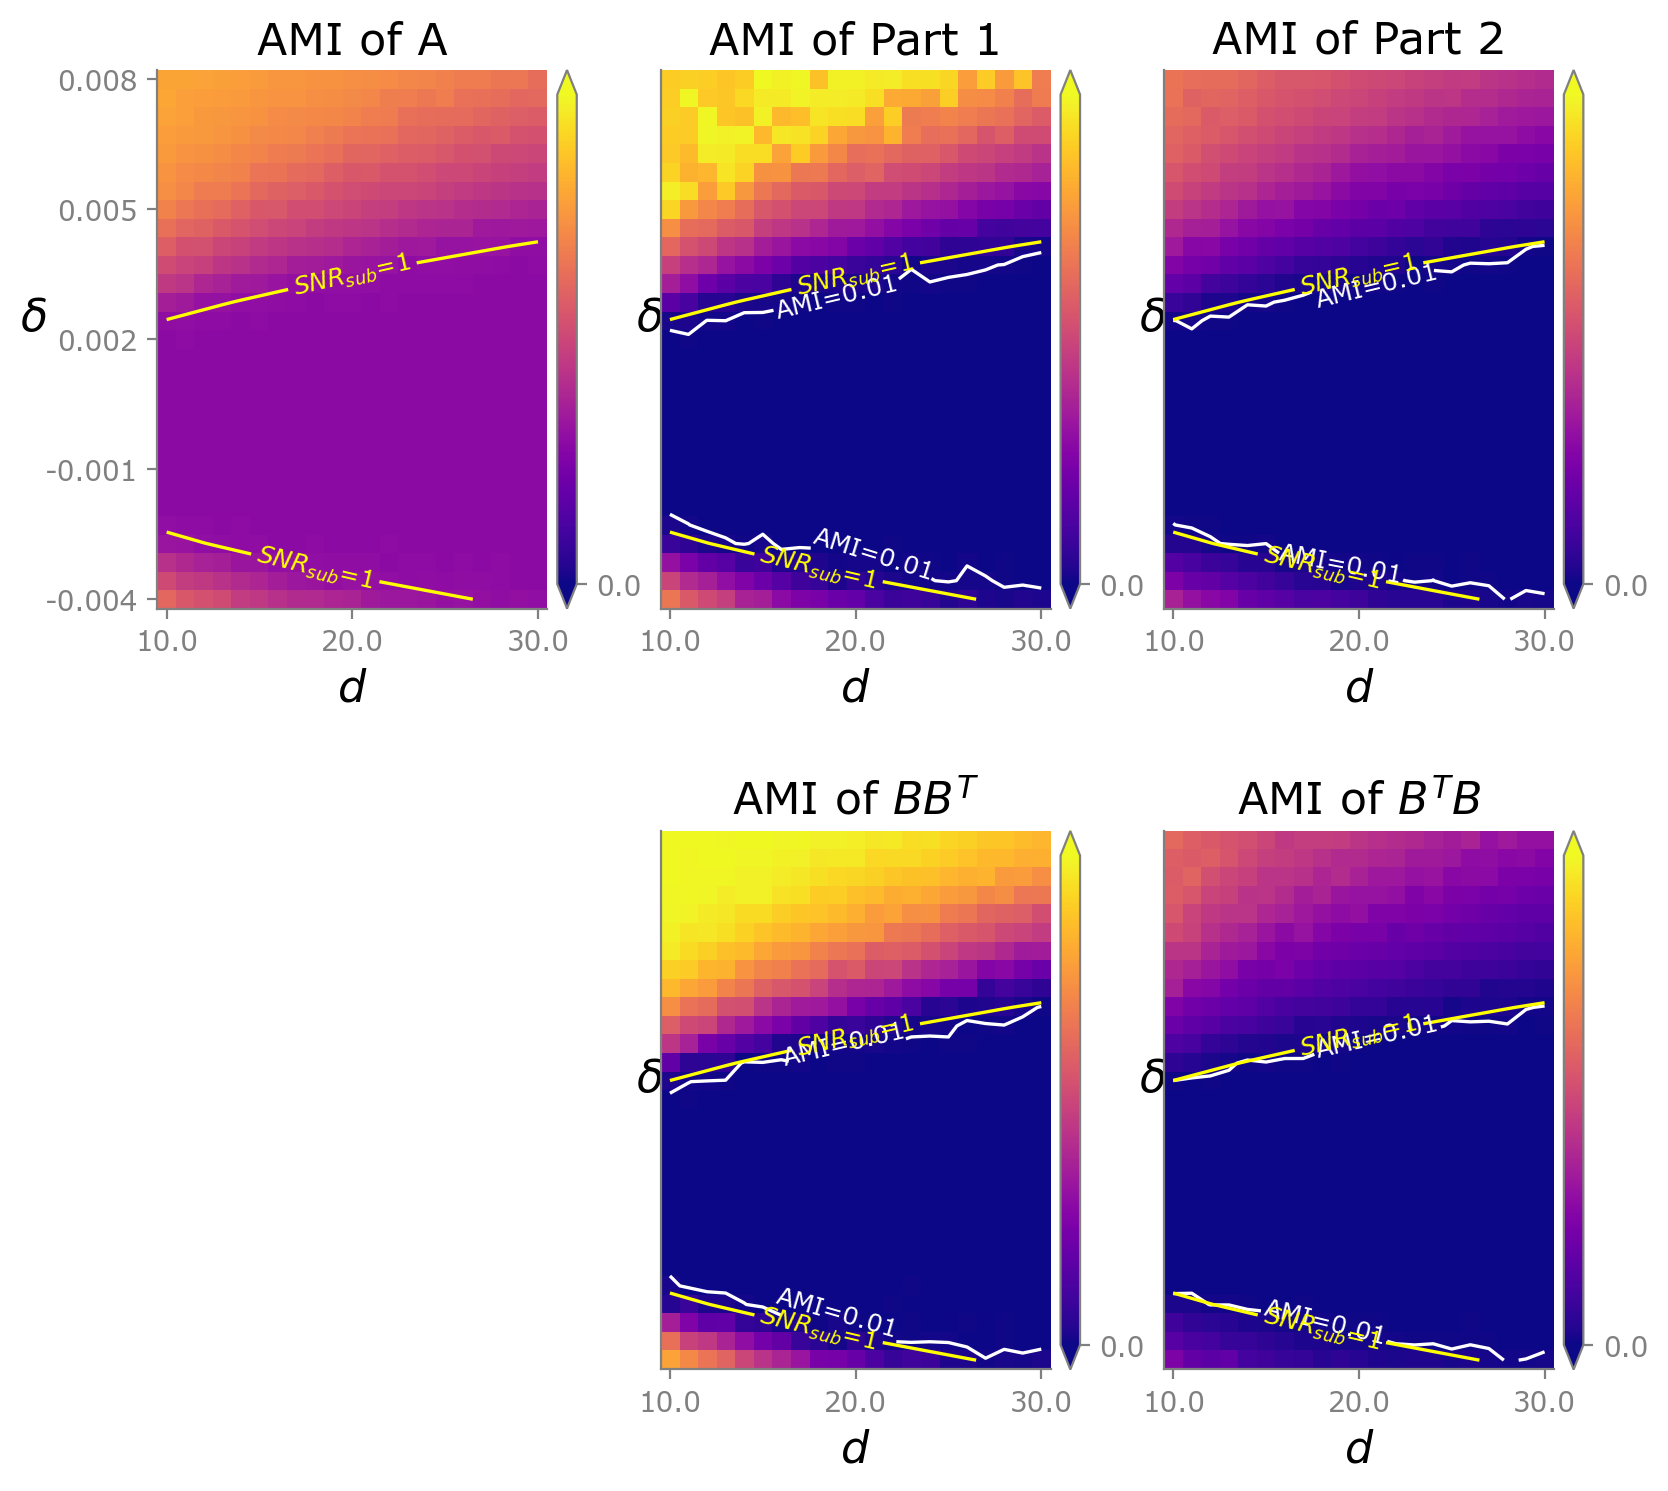

In [29]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(9.2, 14))
widths = [3, 3, 3]
heights = [3, 3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=3, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=A_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=0.1, ami_label="A", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=True)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=Ahalf1_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label="Part 1", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)


row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=Ahalf2_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label="Part 2", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=BBT_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label=r"$BB^T$", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

row = 1
col = 2
ax = fig.add_subplot(spec5[row, col])
ami_contour(fig, ax, plot_x=plot_ds, plot_y=plot_deltas, ami=BTB_ami, addition_contour=n1 / k1 * lambdas[:, 1]**2 / lambdas[:, 0]
            , ami_contour_value=1e-2, ami_label=r"$B^TB$", add_contour_label=r'$SNR_{sub}$', xlabel=r'$d$', ylabel=r'$\delta$', set_yticks=False)

# plt.subplots_adjust(wspace=0.8)
# save_path = "./_Figure/Bipartite/" + "FigureBipartiteAMISNR_" + f'n1_{n1}_n2_{n2}_k1_{k1}_k2_{k2}' + ".png"
# # # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_inches='tight')

# Num Groups of Non-backtracking matrix

## graph generated by BSBM

a=0.0875, b=0.012500000000000004
[0.1   0.075]
SNR of full bipartite network is 5.0, the first partite is 2.8125
number of groups = 4, Kpos=2, Kneg=2
Detect 4 communities, the AMI of partition is 0.9074474712178501


D:\BackProgram\Anaconda\envs\network\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


<Figure size 100x100 with 0 Axes>

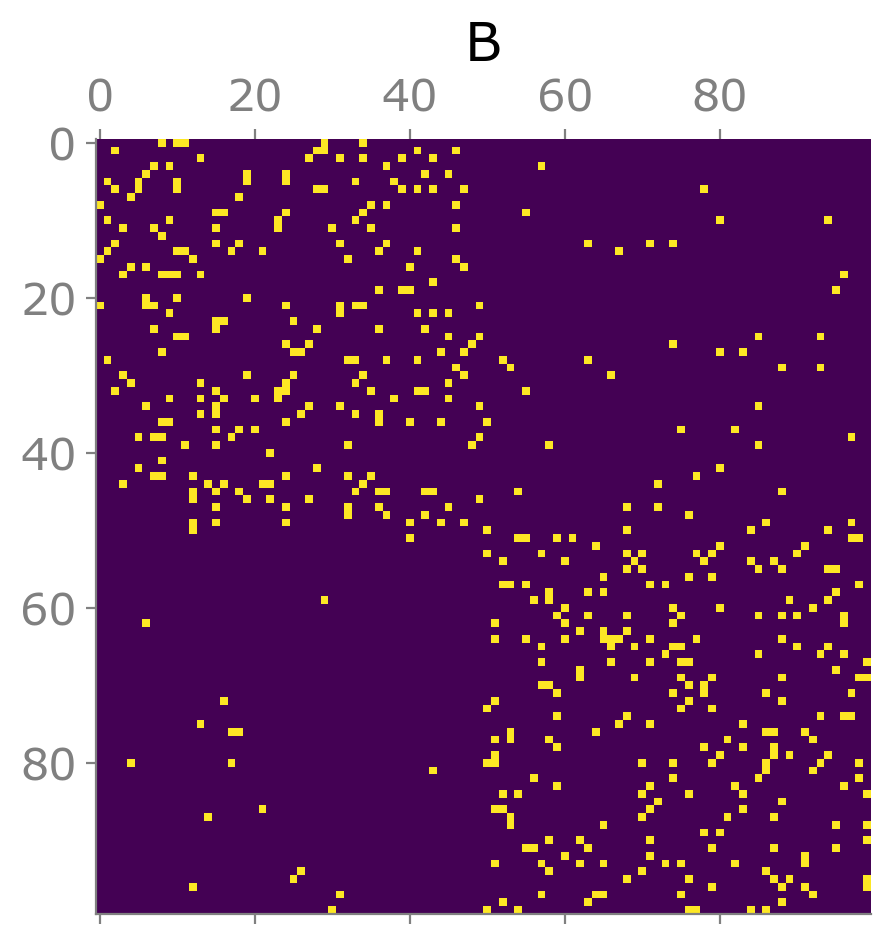

In [7]:
n1 = 100
q1 = 2
d = 5
delta = 0.075
bsbm, partition, numgroups, ami, snr_full, snr_sub1 = symBSBM(n1=n1, q1=q1, delta=delta, d=d, showMat=True, verbose=True)

In [16]:
def get_degree_relation(A):
    degree_x = []
    degree_y = []
    for i in range(n1):
        degree = A[[i], :].sum()
        _, neighbour, _ = find(A[[i], :])
        average_neighbour_degree = 0
        for j in neighbour:
            neighbour_degree = A[:, [j]].sum()
            average_neighbour_degree += neighbour_degree
            # degree_x.append(degree)
            # degree_y.append(neighbour_degree)
        average_neighbour_degree /= np.size(neighbour)
        degree_x.append(degree)
        degree_y.append(average_neighbour_degree)
    return degree_x, degree_y

In [26]:
AA = bsbm.A.dot(bsbm.A)
BBT = AA[:n1, :n1]
vmin, vmax = 0, np.max(BBT)
bulk = np.sqrt((BBT**2).sum() / BBT.shape[0])
print(f'The average degree is {bulk**2}')
NB_BBT = bsbm.get_projection_operator(projection_matrix=BBT, operator='WNB')
eig_NB, _ = eig(NB_BBT.toarray())

The average degree is 64.52000000000001


{34.76466401356173: 1, 24.059293300692683: 1, 12.462249179505719: 1, 11.141308563133357: 1, 9.876170781250618: 1, 8.800277478186695: 1}


Text(0.5, 1.0, 'degree correlation')

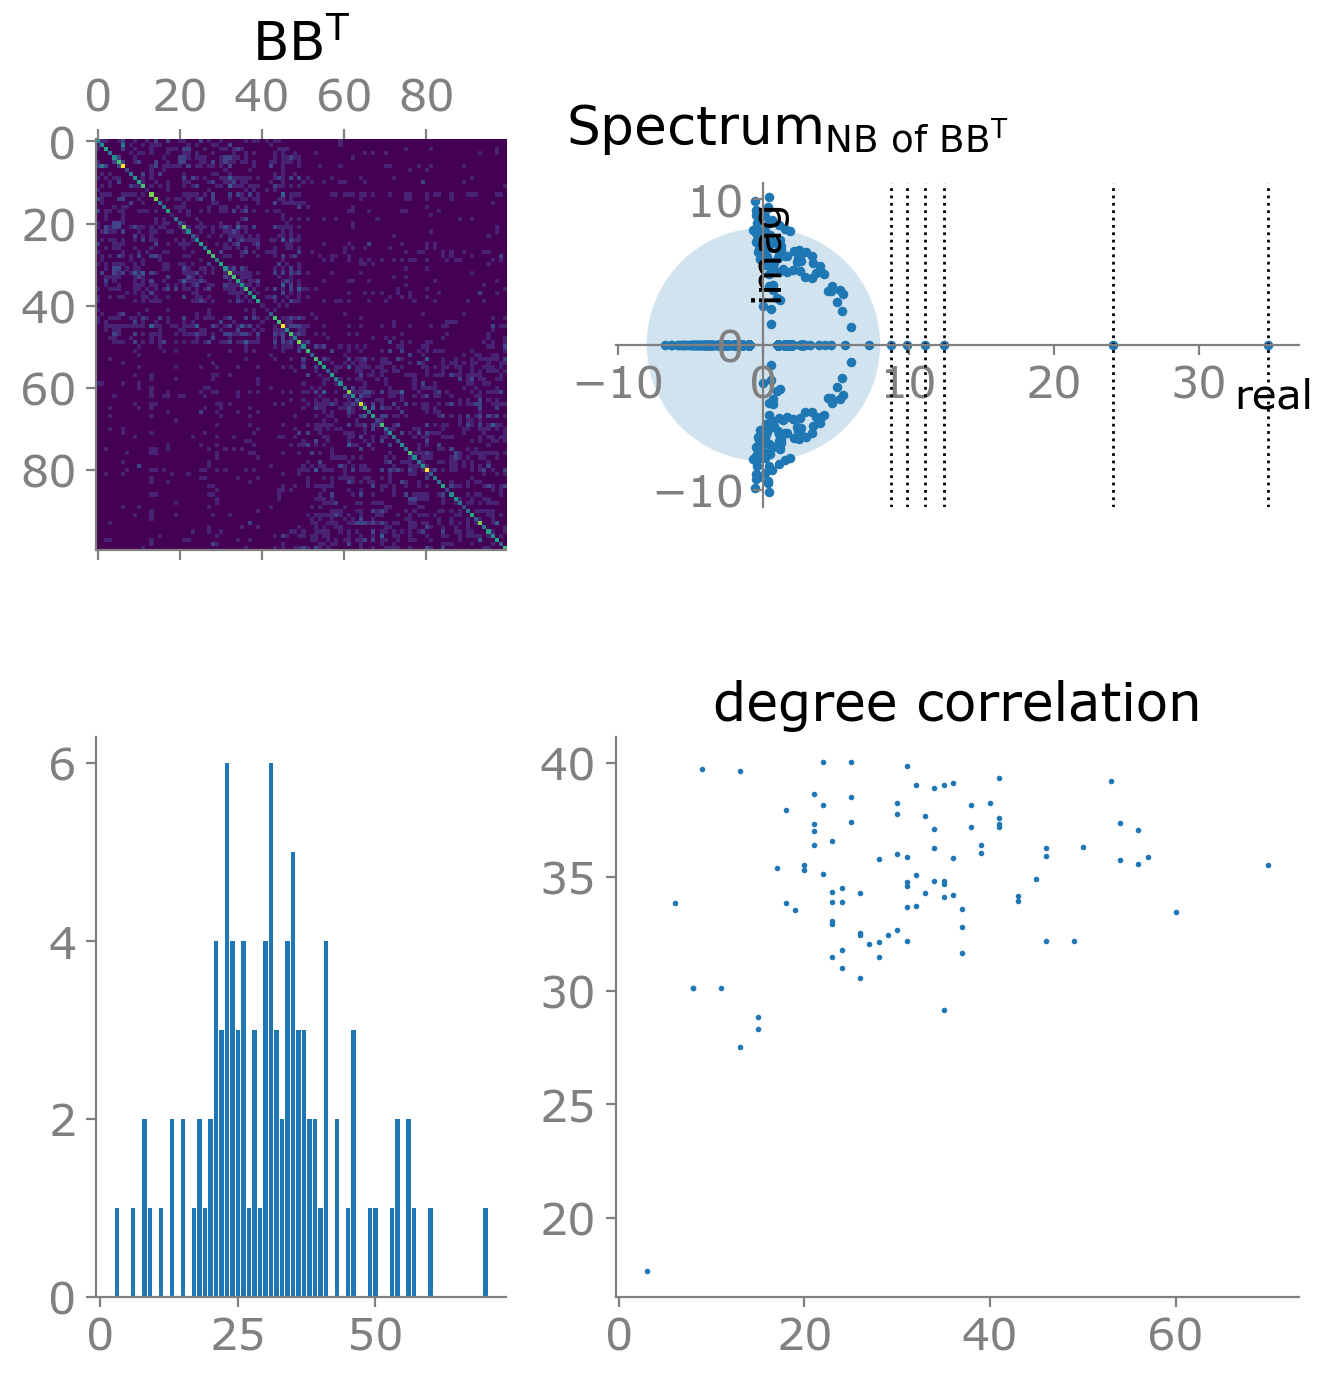

In [27]:
fig = plt.figure(figsize=(12, 8))
widths = [3, 5, 4]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(BBT.toarray(), vmin=vmin, vmax=vmax)
ax.set_title(r'$\rm BB^T$')

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_spectral_NBBH(bsbm, bulk, eig_B=eig_NB, title=r'$\rm Spectrum_{NB\ of\ BB^T}$', ax=ax, fig=fig)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
degree_sequence = BBT.sum(axis=1)
# print(degree_sequence)
ax.bar(*np.unique(degree_sequence, return_counts=True))

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
degree_x, degree_y = get_degree_relation(BBT)
ax.scatter(degree_x, degree_y, s=1)
ax.set_title(f'degree correlation')

In [28]:
a=0.0875
b=0.012500000000000004
omega_p = n1 * (1/q1 * a**2 + (q1-1)/q1 * b**2)
omega_q = n1 * (2/q1 * a * b + (q1-2)/q1 * b**2)
print(omega_p, omega_q)
sizes = [int(n1 / q1)] * q1
omegas = omega_q * np.ones(q1) + (omega_p-omega_q)*np.identity(q1)
psbm = PoissonSBM(sizes, omegas)
bulk = np.sqrt((psbm.A**2).sum() / psbm.A.shape[0])
NB_A = bsbm.get_projection_operator(projection_matrix=psbm.A, operator='WNB')
eig_NB, _ = eig(NB_A.toarray())

0.39062499999999994 0.10937500000000003


4950it [00:00, 60941.00it/s]


{23.818931370649352: 1, 11.879171908419355: 1}


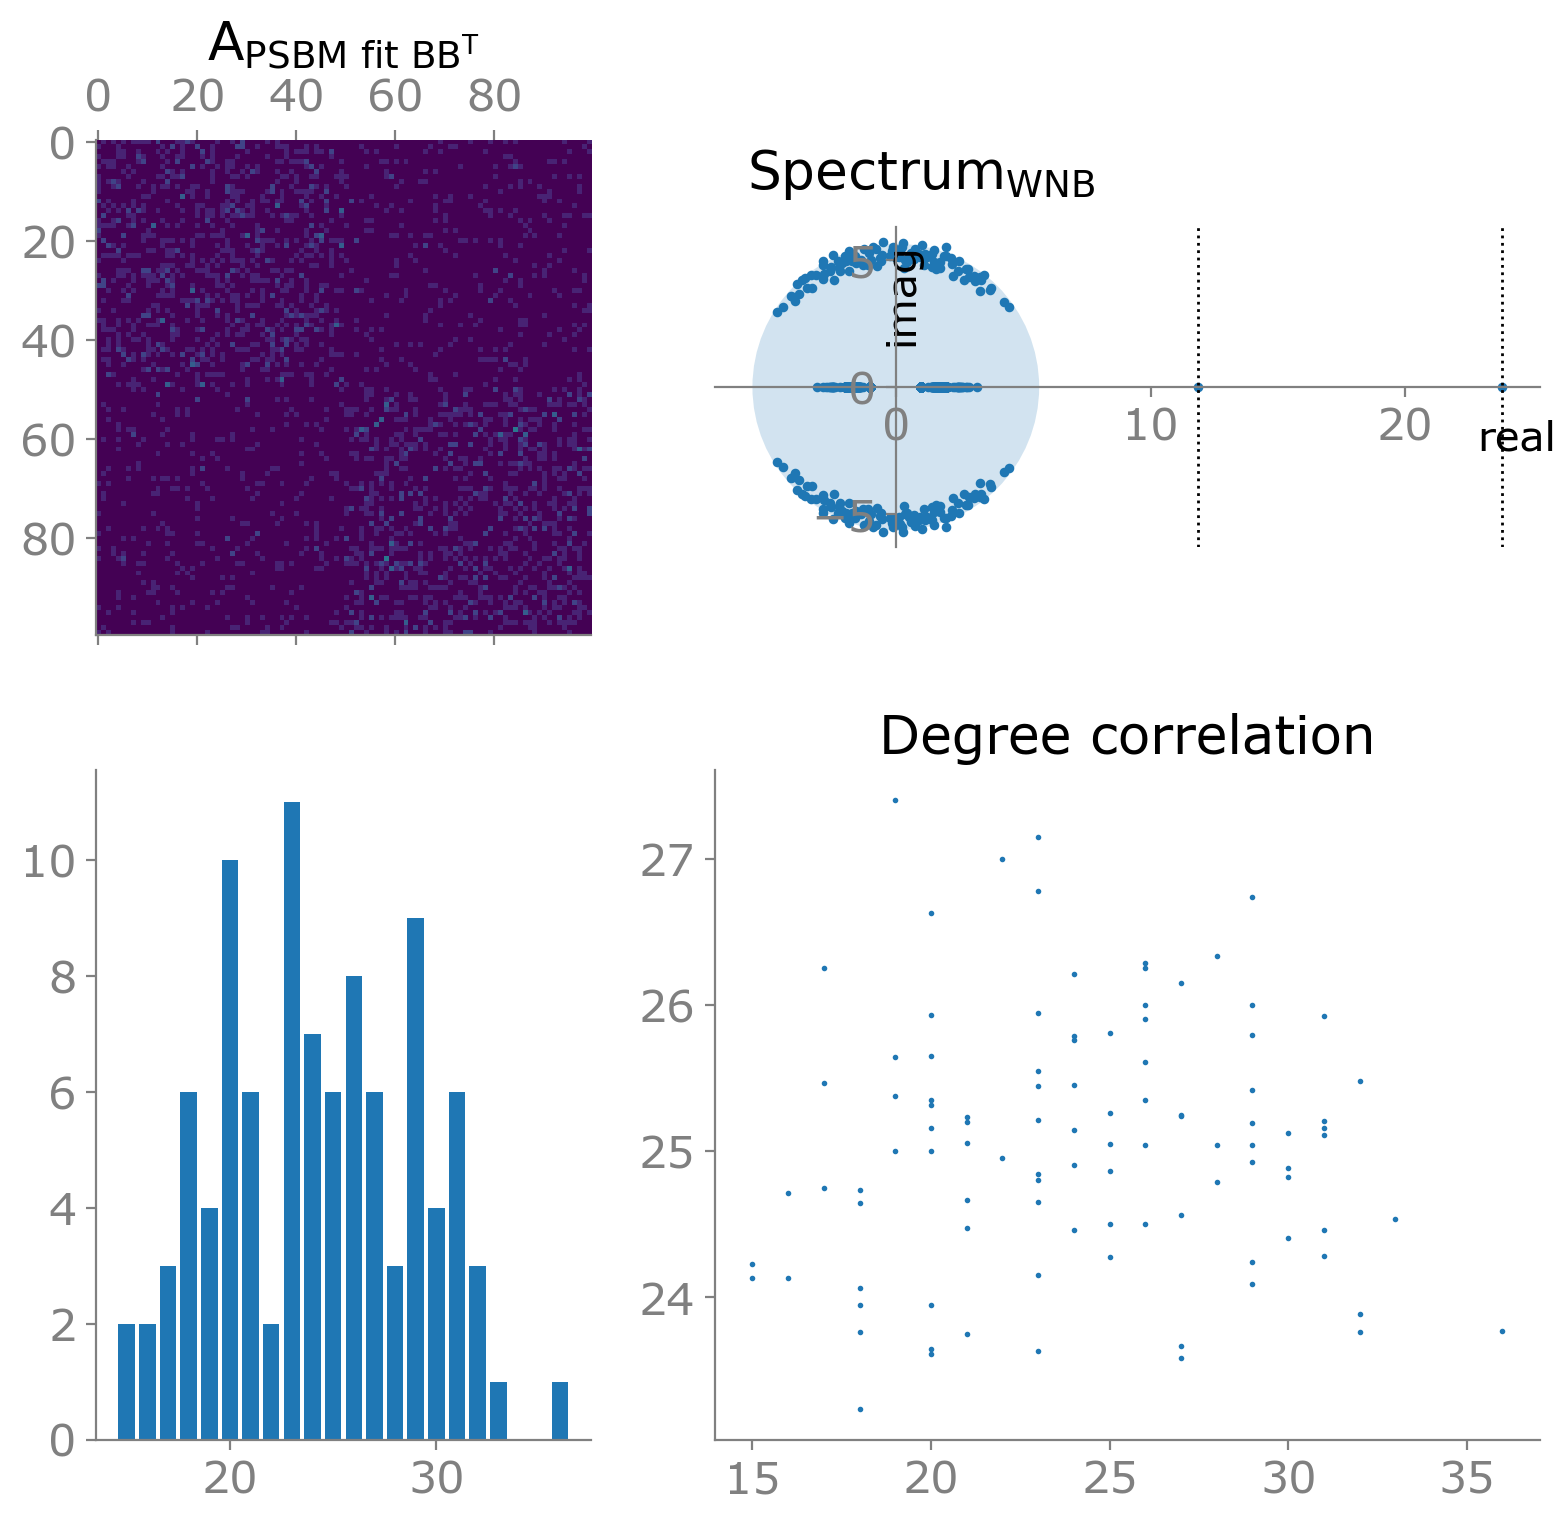

In [29]:
fig = plt.figure(figsize=(12, 8))
widths = [3, 5, 4]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(psbm.A.toarray(), vmin=vmin, vmax=vmax)
ax.set_title(r'$\rm A_{PSBM\ fit\ BB^T}$')

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_spectral_NBBH(bsbm, bulk, eig_B=eig_NB, title=r'$\rm Spectrum_{WNB}$', ax=ax, fig=fig)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
degree_sequence = psbm.A.sum(axis=1)
ax.bar(*np.unique(degree_sequence, return_counts=True))

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
degree_x, degree_y = get_degree_relation(psbm.A)
ax.scatter(degree_x, degree_y, s=1)
ax.set_title(f'Degree correlation')
plt.tight_layout()

In [30]:
AA = AA - diags(np.diag(AA.toarray()), 0)
BBT = AA[:n1, :n1]
bulk = np.sqrt((BBT**2).sum() / BBT.shape[0])
NB_BBT = bsbm.get_projection_operator(projection_matrix=BBT, operator='WNB')
eig_NB, _ = eig(NB_BBT.toarray())

{29.069650646530174: 1, 18.69769178395135: 1, 6.075951322179226: 1}


Text(0.5, 1.0, 'Degree correlation')

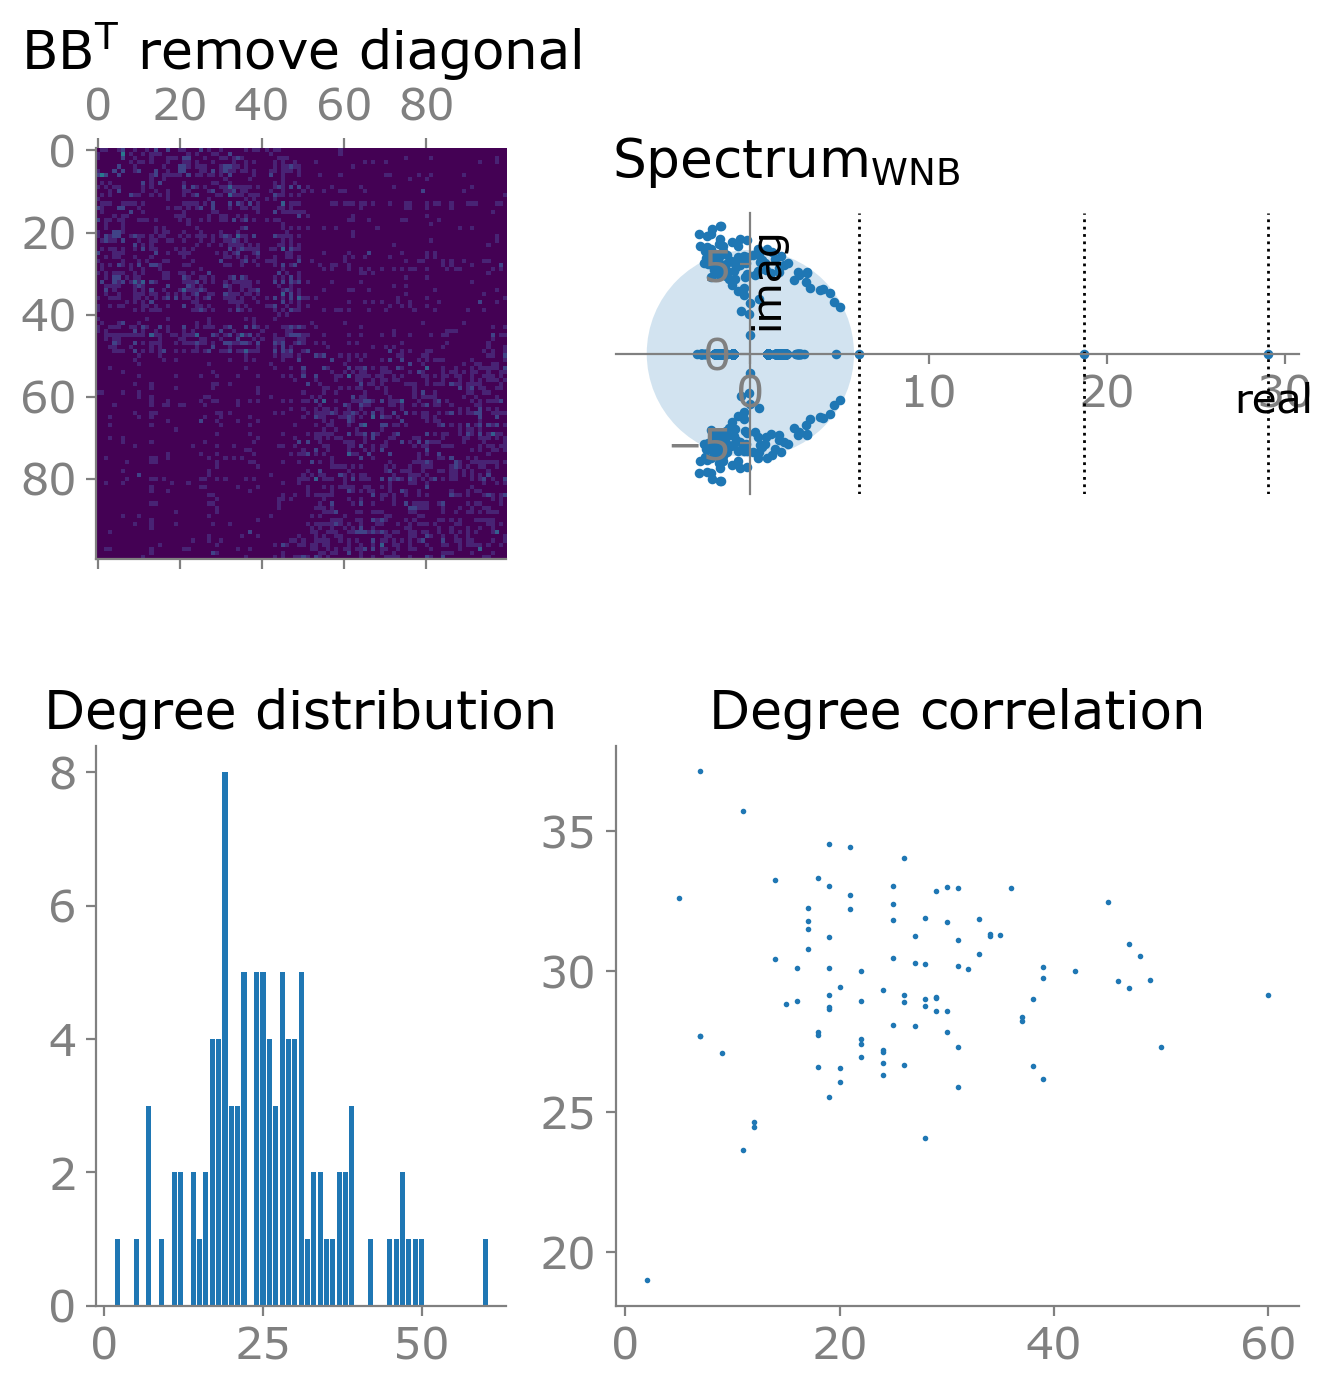

In [32]:
fig = plt.figure(figsize=(12, 8))
widths = [3, 5, 4]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(BBT.toarray(), vmin=vmin, vmax=vmax)
ax.set_title(r'$\rm BB^T$ remove diagonal')

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_spectral_NBBH(bsbm, bulk, eig_B=eig_NB, title=r'$\rm Spectrum_{WNB}$', ax=ax, fig=fig)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
degree_sequence = BBT.sum(axis=1)
ax.bar(*np.unique(degree_sequence, return_counts=True))
ax.set_title(f'Degree distribution')

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
degree_x, degree_y = get_degree_relation(BBT)
ax.scatter(degree_x, degree_y, s=1)
ax.set_title(f'Degree correlation')

In [33]:
AA = AA - diags(np.diag(AA.toarray()), 0)
AA[AA > 0] = 1
BBT = AA[:n1, :n1]
bulk = np.sqrt((BBT**2).sum() / BBT.shape[0])
NB_BBT = bsbm.get_projection_operator(projection_matrix=BBT, operator='WNB')
eig_NB, _ = eig(NB_BBT.toarray())

{24.03818258757989: 1, 14.444389672608736: 1, 5.701736214550247: 1}


Text(0.5, 1.0, 'Degree correlation')

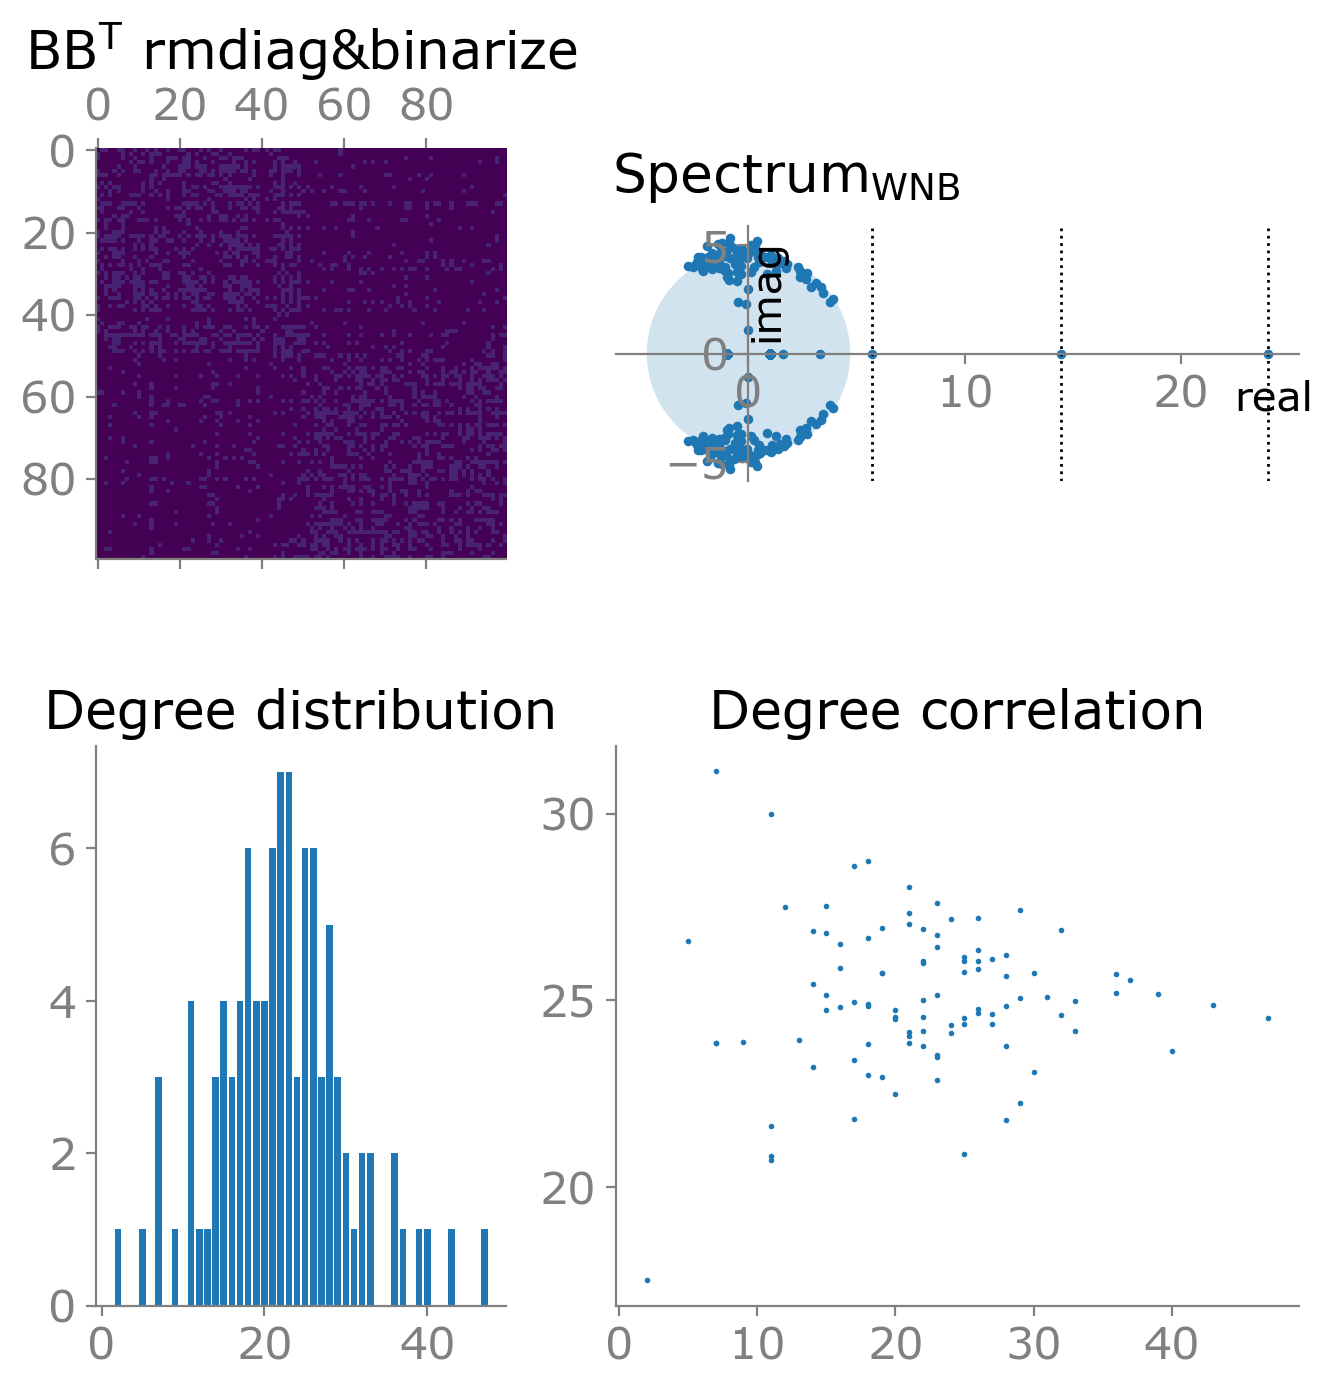

In [34]:
fig = plt.figure(figsize=(12, 8))
widths = [3, 5, 4]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(BBT.toarray(), vmin=vmin, vmax=vmax)
ax.set_title(r'$\rm BB^T$ rmdiag&binarize')

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_spectral_NBBH(bsbm, bulk, eig_B=eig_NB, title=r'$\rm Spectrum_{WNB}$', ax=ax, fig=fig)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
degree_sequence = BBT.sum(axis=1)
ax.bar(*np.unique(degree_sequence, return_counts=True))
ax.set_title(f'Degree distribution')

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
degree_x, degree_y = get_degree_relation(BBT)
ax.scatter(degree_x, degree_y, s=1)
ax.set_title(f'Degree correlation')

## graph generated by HSBM

Generating hyper edges for order 2...
	 group set (0, 0) have 60 hedges
	 group set (0, 1) have 12 hedges
	 group set (0, 2) have 12 hedges
	 group set (0, 3) have 12 hedges
	 group set (1, 1) have 60 hedges
	 group set (1, 2) have 12 hedges
	 group set (1, 3) have 12 hedges
	 group set (2, 2) have 60 hedges
	 group set (2, 3) have 12 hedges
	 group set (3, 3) have 60 hedges
Generating hyper edges for order 3...
	 group set (0, 0, 0) have 4 hedges
	 group set (0, 0, 1) have 1 hedges
	 group set (0, 0, 2) have 1 hedges
	 group set (0, 0, 3) have 1 hedges
	 group set (0, 1, 1) have 1 hedges
	 group set (0, 1, 2) have 3 hedges
	 group set (0, 1, 3) have 3 hedges
	 group set (0, 2, 2) have 1 hedges
	 group set (0, 2, 3) have 3 hedges
	 group set (0, 3, 3) have 1 hedges
	 group set (1, 1, 1) have 4 hedges
	 group set (1, 1, 2) have 1 hedges
	 group set (1, 1, 3) have 1 hedges
	 group set (1, 2, 2) have 1 hedges
	 group set (1, 2, 3) have 3 hedges
	 group set (1, 3, 3) have 1 hedges
	 group 

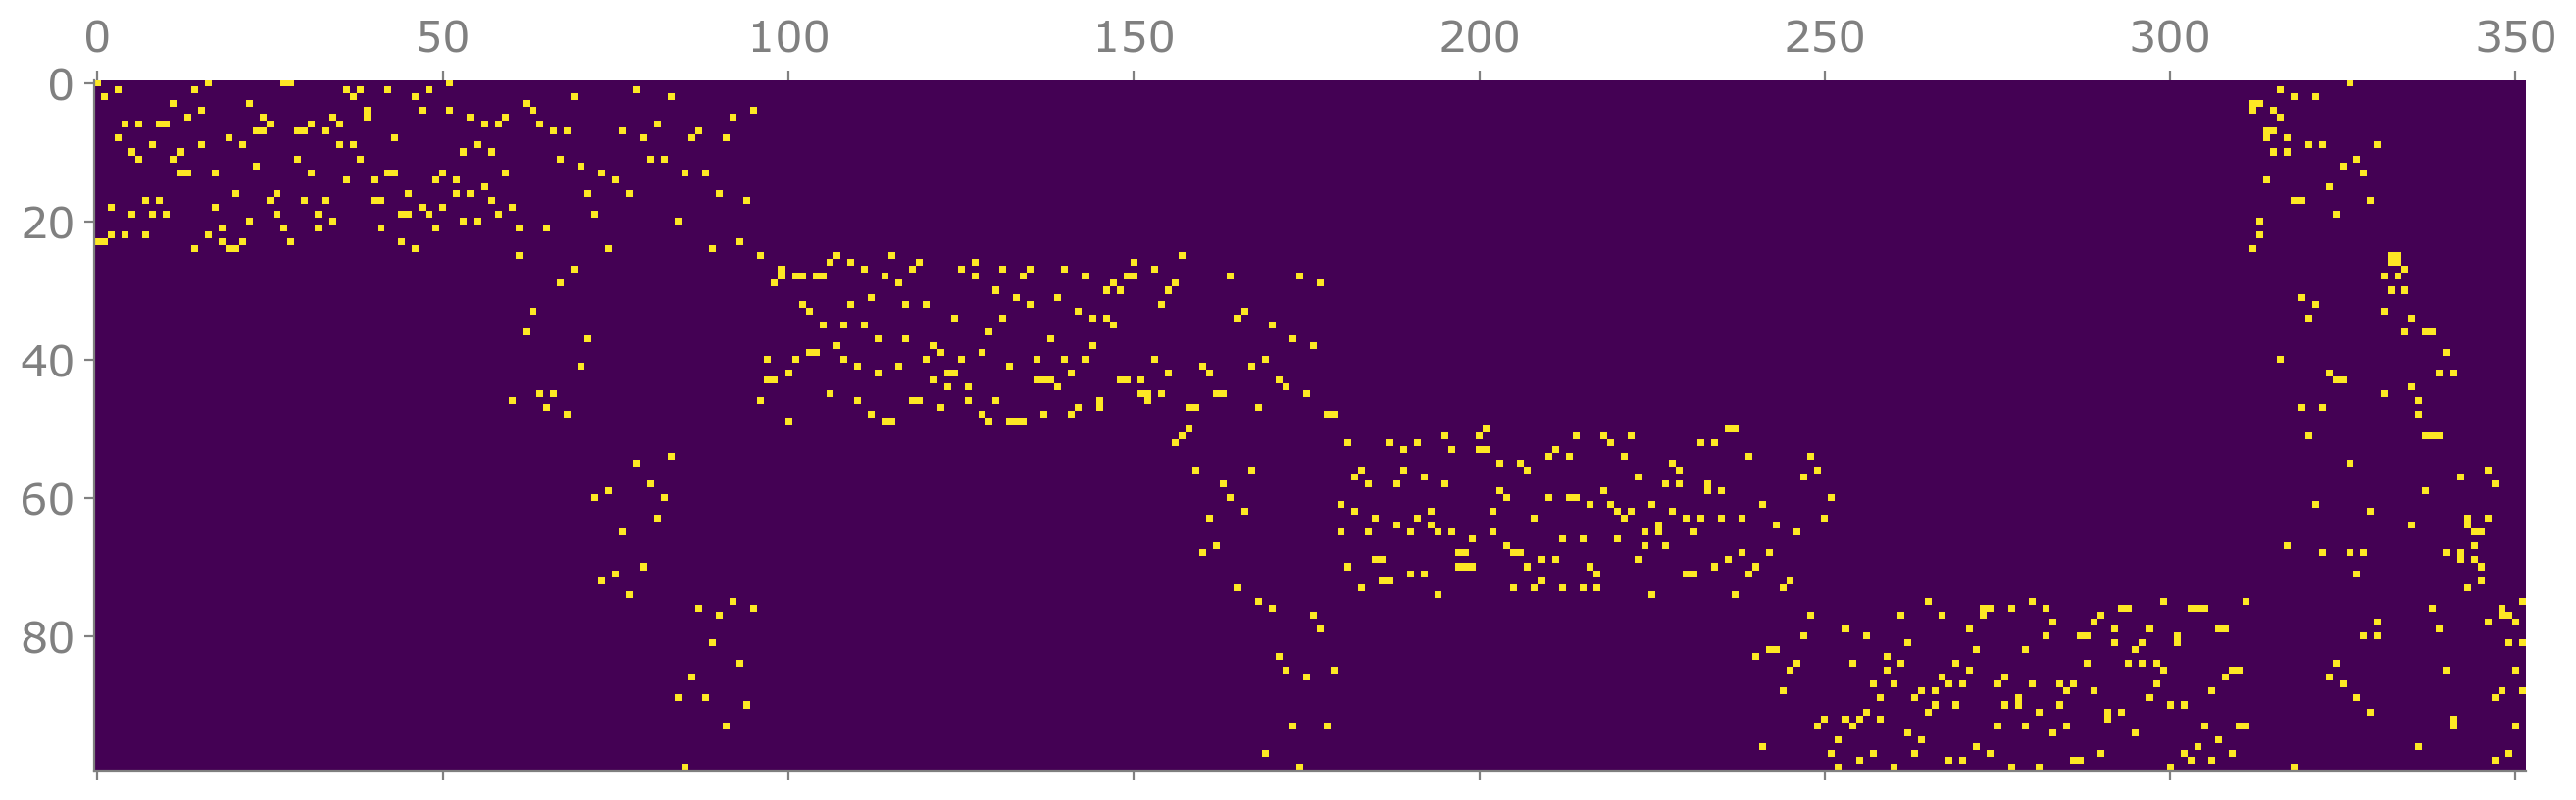

In [34]:
n = 100
q = 4
Ks = [2, 3, 4]
cin = 20
cout = 2
hsbm = UnUniformSymmetricHSBM(n, q, Ks, cin, cout, slow=False)
plt.matshow(hsbm.H.toarray())
print(np.unique(hsbm.H.toarray()))

In [35]:
edge_order, edge_count = np.unique(hsbm.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
ds = dict()
for o in order_count:
    ds[o] = o * order_count[o] / n
bulk = 0
for o in order_count:
    bulk += ds[o] * (o - 1)
bulk = np.sqrt(bulk)
print(f'bulk radius = {bulk}')
print(f'{hsbm.H.sum()}')
NB = hsbm.get_operator('NB')
print(np.shape(NB))
eig_NB, _ = eig(NB.toarray())

{2: 312, 3: 40}
bulk radius = 2.939387691339814
744
Non-backtrack constructing for 744 directed node-hyperEdge pairs...
744


553536it [03:10, 2913.25it/s]


(744, 744)


{9.672367508204982: 1, 5.898832206402629: 1, 4.965207846122698: 1, 3.8589907516854782: 1}


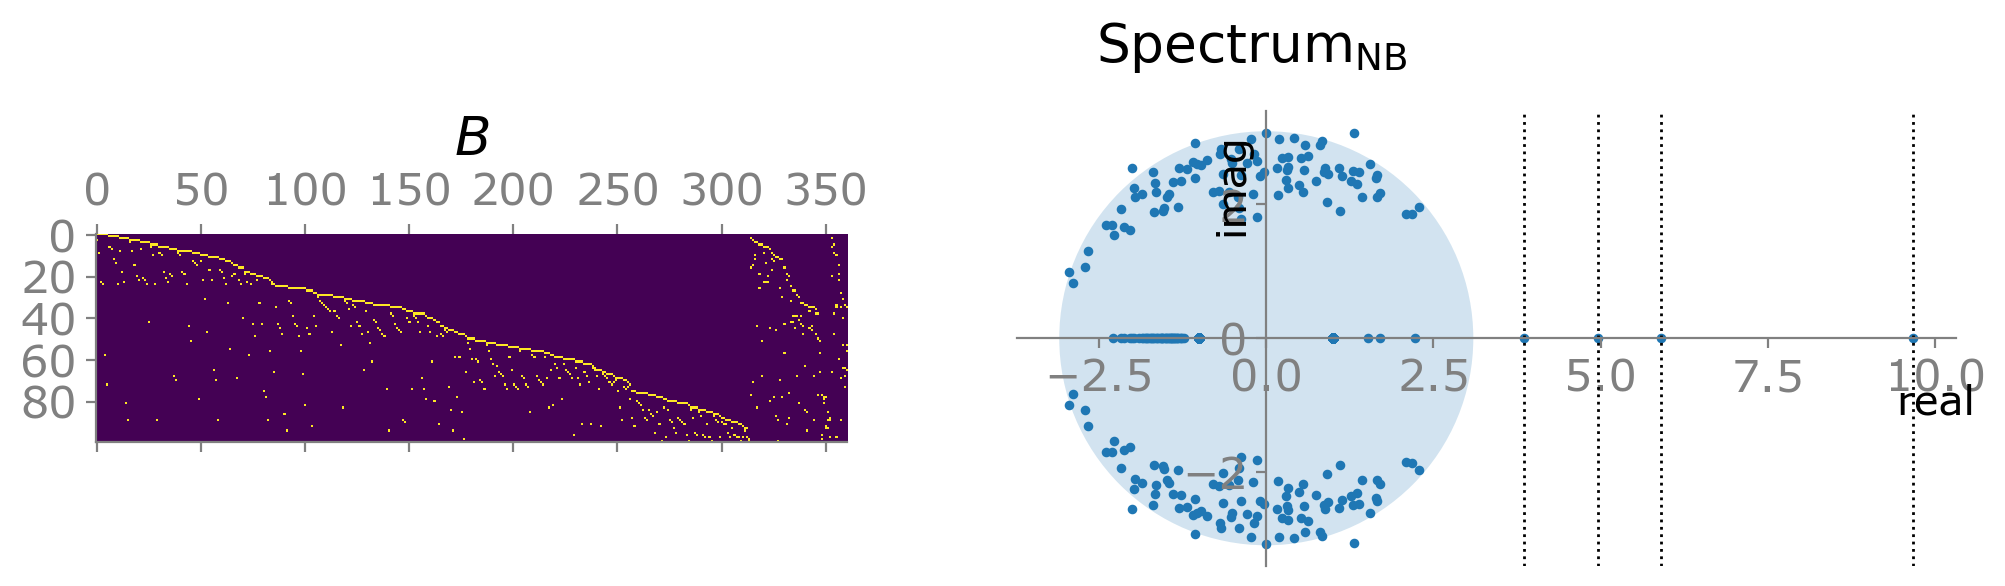

In [17]:
fig = plt.figure(figsize=(12, 8))
widths = [4, 5]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(hsbm.H.toarray())
ax.set_title(r'$B$')

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_spectral_NBBH(hsbm, bulk, eig_B=eig_NB, title=r'$\rm Spectrum_{NB}$', ax=ax, fig=fig)

In [21]:
AA = hsbm.H.dot(hsbm.H.transpose())
BBT = AA[:n, :n]
vmin, vmax = 0, np.max(BBT)
bulk = np.sqrt((BBT**2).sum() / BBT.shape[0])
print(f'The average degree is {bulk**2}')
NB_BBT = hsbm.get_projection_operator(projection_matrix=BBT, operator='WNB')
eig_NB, _ = eig(NB_BBT.toarray())

The average degree is 78.14999999999999


NameError: name 'BBT' is not defined

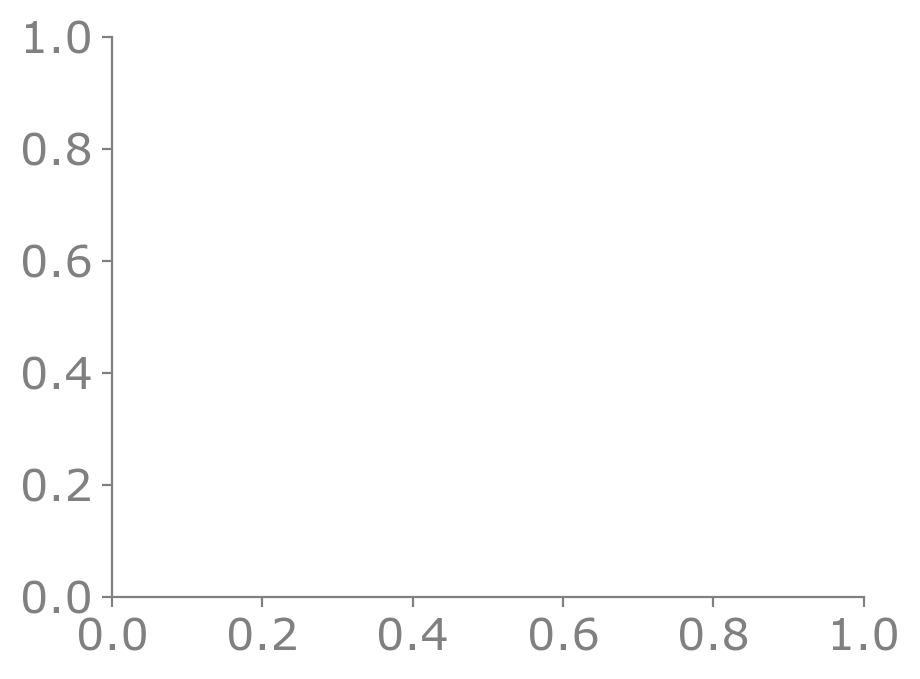

In [10]:
fig = plt.figure(figsize=(12, 8))
widths = [4, 5]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(BBT.toarray())
ax.set_title(r'$\rm BB^T$')

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
plot_spectral_NBBH(hsbm, bulk, eig_B=eig_NB, title=r'$\rm Spectrum_{WNB_{BB^T}}$', ax=ax, fig=fig)

## compare degree distribution


a=0.0075, b=0.0025
[0.01  0.005]
SNR of full bipartite network is 4.999999999999999, the first partite is 1.2500000000000009
number of groups = 2, Kpos=1, Kneg=1
Detect 2 communities, the AMI of partition is 0.6517344239984947


<Figure size 100x100 with 0 Axes>

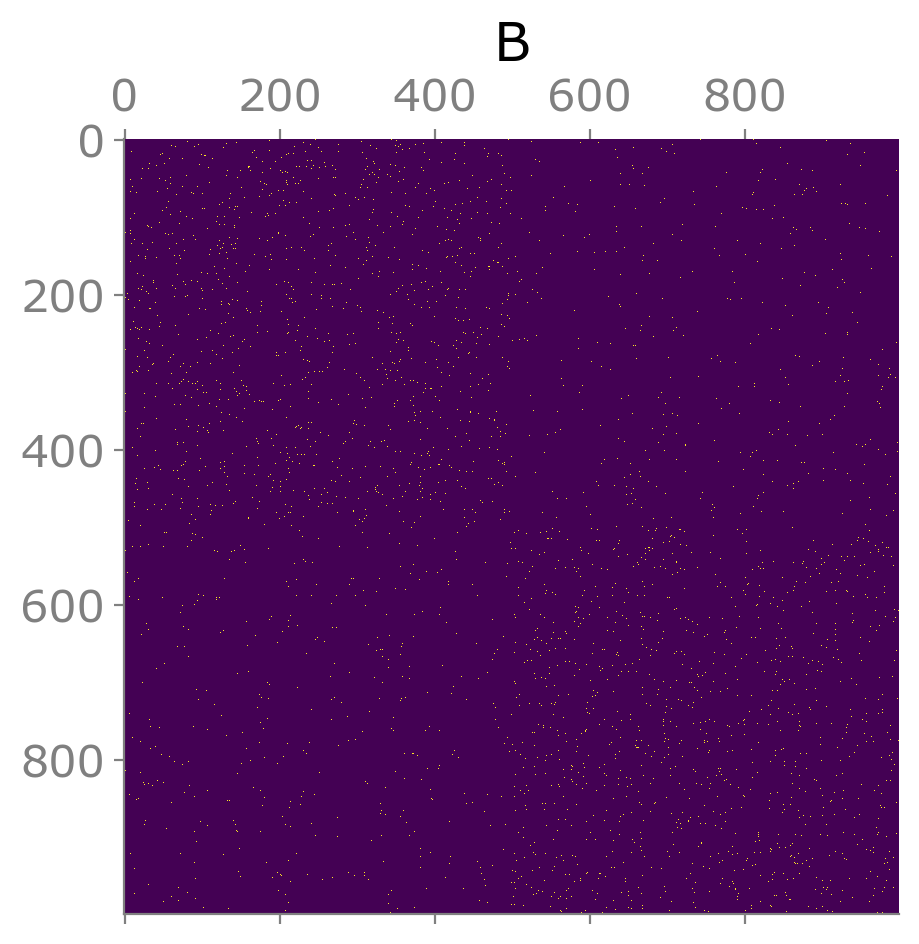

In [18]:
n1 = 1000
q1 = 2
d = 5
delta = 0.005
bsbm, partition, numgroups, ami, snr_full, snr_sub1 = symBSBM(n1=n1, q1=q1, delta=delta, d=d, showMat=True, verbose=True)

In [20]:
a=0.0075
b=0.0025
omega_p = n1 * (1/q1 * a**2 + (q1-1)/q1 * b**2)
omega_q = n1 * (2/q1 * a * b + (q1-2)/q1 * b**2)
print(omega_p, omega_q)
sizes = [int(n1 / q1)] * q1
omegas = omega_q * np.ones(q1) + (omega_p-omega_q)*np.identity(q1)
psbm = PoissonSBM(sizes, omegas)

0.03125 0.01875


0it [00:00, ?it/s]D:\Work\PhD\_code\_nodeclassification\_SBMMatrix.py:232: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.A[index] = w
499500it [00:07, 71004.00it/s]


Text(0.5, 1.0, '$\\rm A_{PSBM\\ fit\\ BB^T}$')

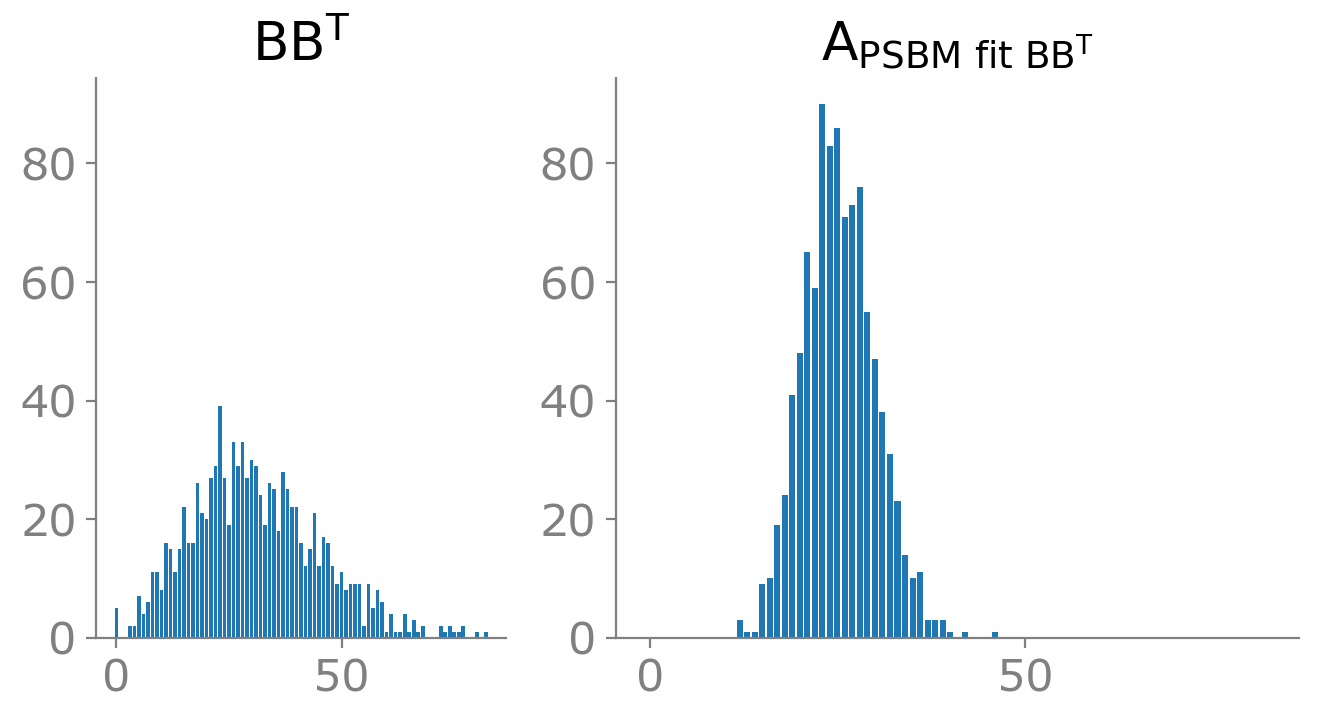

In [26]:
fig = plt.figure(figsize=(12, 8))
widths = [3, 5, 4]
heights = [3, 3]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax0 = fig.add_subplot(spec5[row, col])
AA = bsbm.A.dot(bsbm.A)
# AA = AA - diags(np.diag(AA.toarray()), 0)
BBT = AA[:n1, :n1]
degree_sequence = BBT.sum(axis=1)
# print(degree_sequence)
ax0.bar(*np.unique(degree_sequence, return_counts=True))
ax0.set_title(r'$\rm BB^T$')

row = 0
col = 1
ax1 = fig.add_subplot(spec5[row, col])
ax1.sharex(ax0)
ax1.sharey(ax0)
degree_sequence = psbm.A.sum(axis=1)
ax1.bar(*np.unique(degree_sequence, return_counts=True))
ax1.set_title(r'$\rm A_{PSBM\ fit\ BB^T}$')

# Illustration Figure

In [6]:
n1 = 300
n2 = 400
k1 = 3
k2 = 4
delta = 0.05
d = 10
p = (7 * d) / (8 * n1) + delta / 2
q = (7 * d) / (8 * n1) - delta / 2
p = np.around(p, 5)
q = np.around(q, 5)
min_delta, max_delta = generate_delta_range(n1, n2, k1, k2, d, Htype=1)
print(f'--For asymmetric case k1={k1} k2={k2}, d={d}, Range of delta ({min_delta}, {max_delta}). '
      f'Now delta={delta} which make p_diagonal_B={p}, p_offdiagonal_B={q}')
# Construct bipartite graph
sizes = [int(n1 / k1)] * k1 + [int(n2 / k2)] * k2
H = np.array([[p, p, q, q], [q, p, p, q], [q, q, p, p]])
bsbm = BipartiteSBM(k1, k2, sizes, H)

--For asymmetric case k1=3 k2=4, d=10, Range of delta (-0.058333333333333334, 0.058333333333333334). Now delta=0.05 which make p_diagonal_B=0.05417, p_offdiagonal_B=0.00417


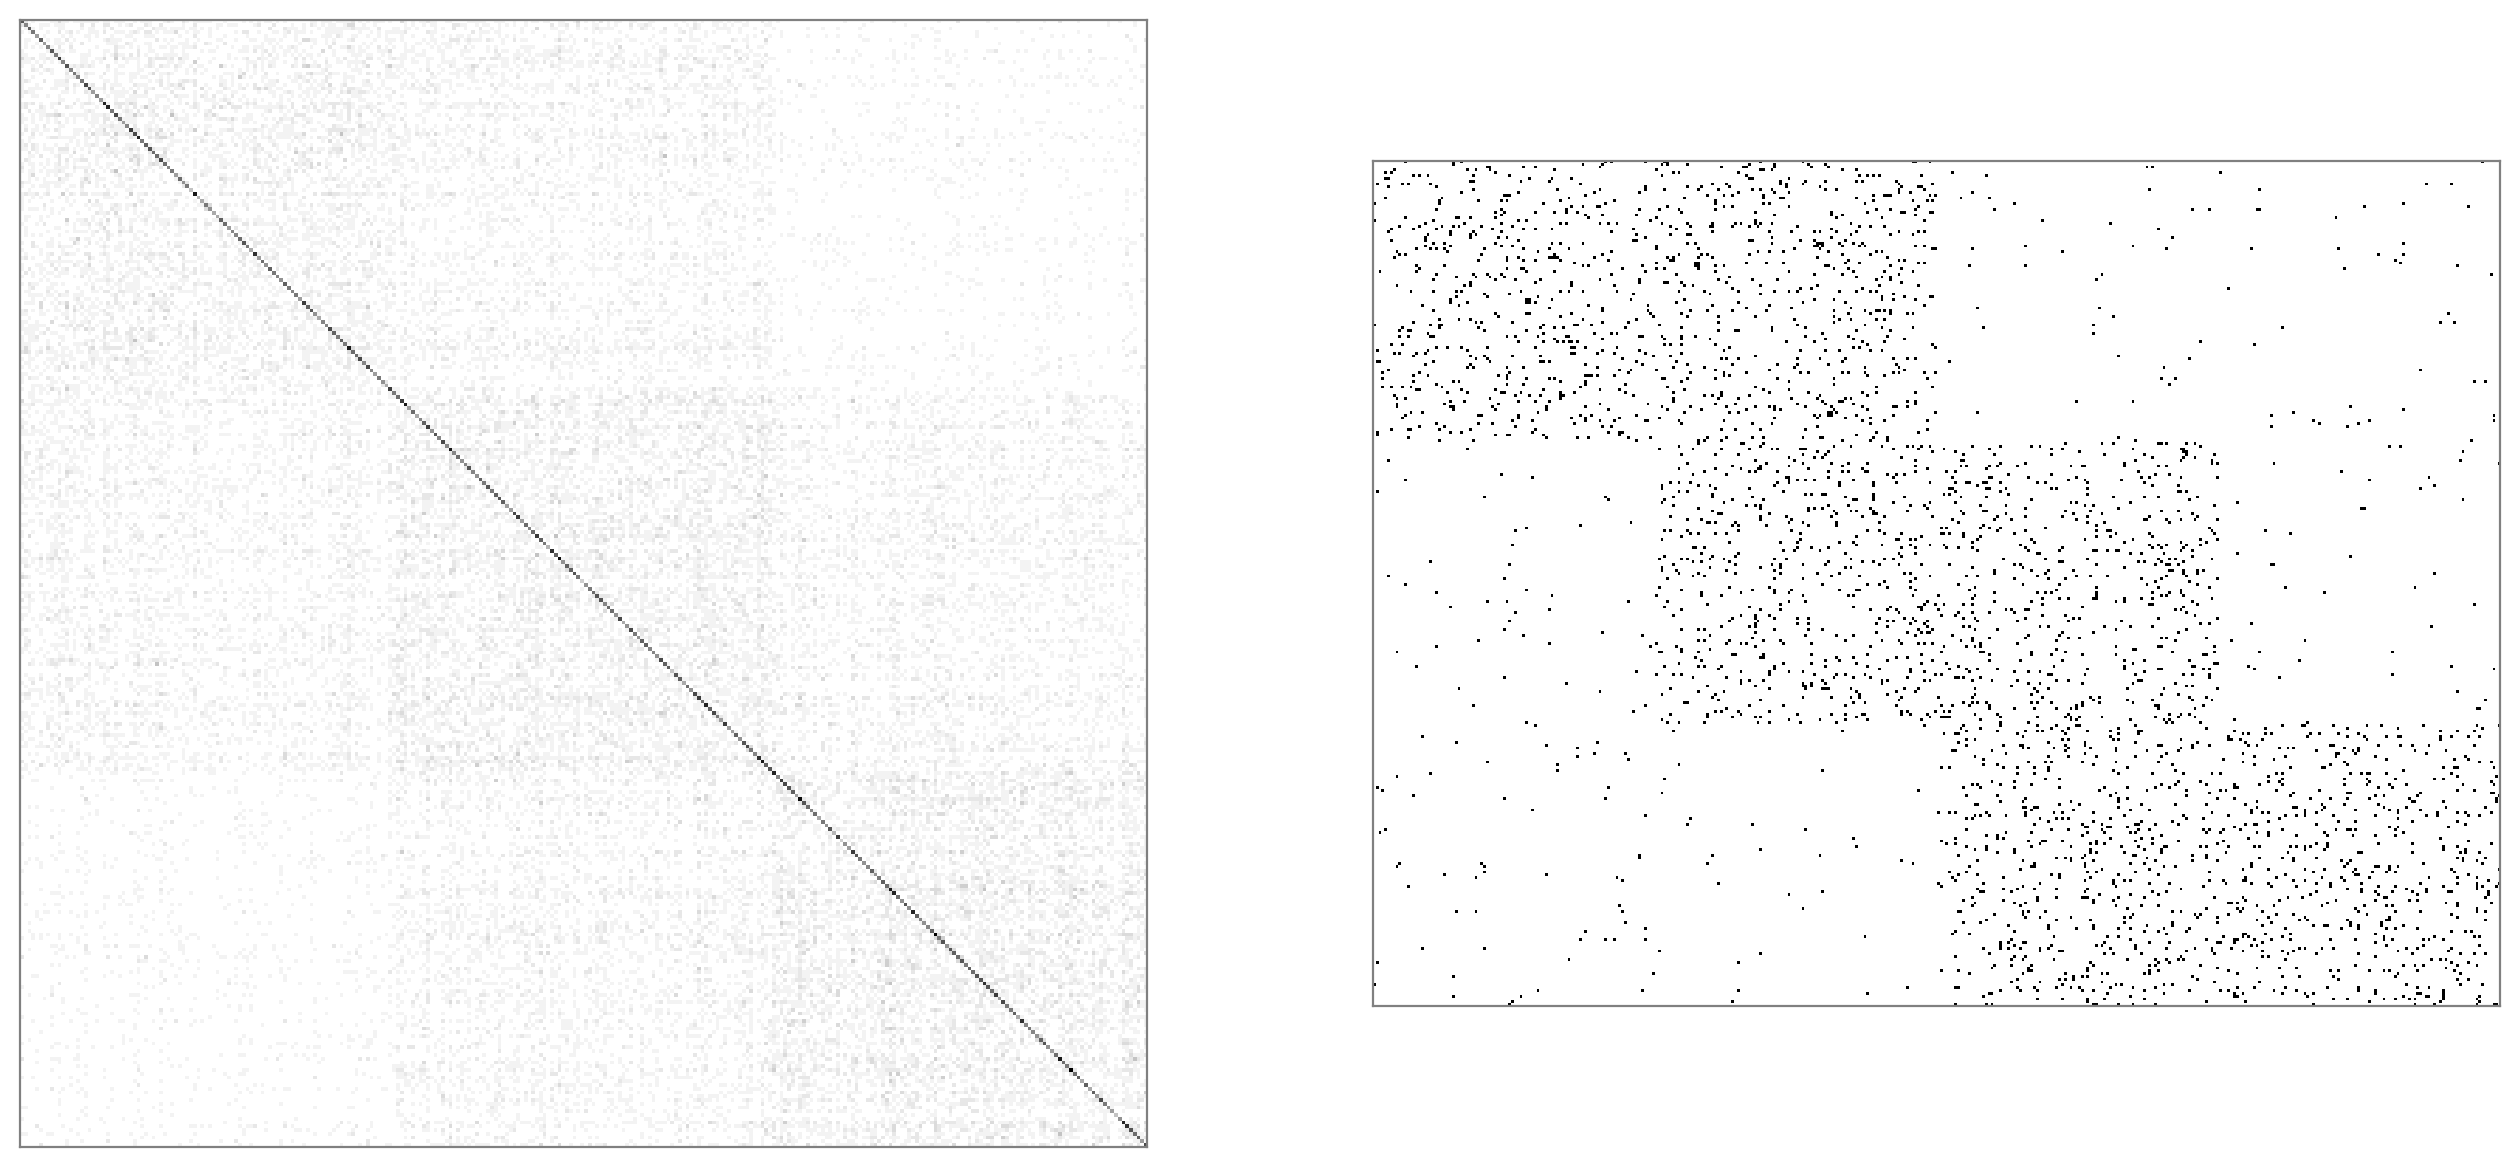

In [9]:
fig = plt.figure(figsize=(16, 8))
widths = [4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.matshow(bsbm.A[:n1, n1:].dot(bsbm.A[:n1, n1:].transpose()).toarray(), cmap=plt.cm.gray_r)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top']].set_visible(True)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
ax.matshow(bsbm.A[:n1, n1:].toarray(), cmap=plt.cm.gray_r)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top']].set_visible(True)

In [8]:
import numpy as np
np.linspace(0.5, 10, 58)

array([ 0.5       ,  0.66666667,  0.83333333,  1.        ,  1.16666667,
        1.33333333,  1.5       ,  1.66666667,  1.83333333,  2.        ,
        2.16666667,  2.33333333,  2.5       ,  2.66666667,  2.83333333,
        3.        ,  3.16666667,  3.33333333,  3.5       ,  3.66666667,
        3.83333333,  4.        ,  4.16666667,  4.33333333,  4.5       ,
        4.66666667,  4.83333333,  5.        ,  5.16666667,  5.33333333,
        5.5       ,  5.66666667,  5.83333333,  6.        ,  6.16666667,
        6.33333333,  6.5       ,  6.66666667,  6.83333333,  7.        ,
        7.16666667,  7.33333333,  7.5       ,  7.66666667,  7.83333333,
        8.        ,  8.16666667,  8.33333333,  8.5       ,  8.66666667,
        8.83333333,  9.        ,  9.16666667,  9.33333333,  9.5       ,
        9.66666667,  9.83333333, 10.        ])